# Clasificación y relevancia de variables — Sprint 3

---

## Estructura del notebook

| Sección | Descripción |
|---------|-------------|
| 0 | Importaciones y configuración global |
| 1 | Carga y preparación de datos |
| **EXP 1** | Todas las posiciones — 6 clases |
| **EXP 2** | Posiciones agrupadas (LW+RW→Wing, LB+RB→Lateral) — 4 clases |
| Final | Entrenamiento sobre el dataset completo (train+test) para modelo robusto |

## 0. Importaciones y configuración

In [1]:
import os, math, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score,
    train_test_split, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
    f1_score, precision_score, recall_score
)
import xgboost as xgb

# ── Directorios de salida ────────────────────────────────────
OUT_ROOT = 'position_output'
for d in [OUT_ROOT, f'{OUT_ROOT}/exp1', f'{OUT_ROOT}/exp2', f'{OUT_ROOT}/final']:
    os.makedirs(d, exist_ok=True)

# ── Paleta de colores ────────────────────────────────────────
POS_COLORS = {
    'LW': '#3266ad', 'RW': '#7f77dd',
    'LB': '#d85a30', 'RB': '#ba7517',
    'CB': '#1d9e75',
    'LP': '#d4537e',
    # Grupos (Exp 2)
    'Wing':    '#3266ad',
    'Lateral': '#d85a30',
    'Central': '#1d9e75',
    'Pivote':  '#d4537e',
}

RANDOM_STATE = 42
print('Configuración lista.')

Configuración lista.


## 1. Carga y preparación de datos

In [2]:
ruta_csv = 'EHF2024-M-AGGREGATED.csv'
df_raw = pd.read_csv(ruta_csv)

# ── Variables excluidas
COLS_DROP = ['Unnamed: 0', 'Team', 'No', 'Name',
             'scoring', 'topk', 'top1', 'R7', 'P7',
             'RC', 'Time', '2+2']          # <-- eliminadas según requisito

FEATURE_COLS = [
    '7mPGoals', '7mPMissed',
    '6mCGoals', '6mCMissed',
    'WingGoals', 'WingMissed',
    'BTGoals',  'BTMissed',
    'FBGoals',  'FBMissed',
    'FTOGoals', 'FTOMissed',
    '9mGoals',  '9mMissed',
    '2M', 'AS', 'ST', 'BS', 'TO'
]
TARGET_COL = 'Position'

df_full = df_raw[FEATURE_COLS + [TARGET_COL]].copy()
df_full[TARGET_COL] = df_full[TARGET_COL].astype(str).str.strip()
df_full = df_full.dropna()

print(f'Dataset completo: {df_full.shape[0]} jugadores, {len(FEATURE_COLS)} variables')
print('\nDistribución original de posiciones:')
print(df_full[TARGET_COL].value_counts())

Dataset completo: 427 jugadores, 19 variables

Distribución original de posiciones:
Position
LB    83
LP    72
CB    64
GK    56
RB    56
RW    50
LW    46
Name: count, dtype: int64


---

# ══════════════════════════════════════════
# EXPERIMENTO 1 — Todas las posiciones
# (LW, RW, LB, RB, CB, LP — 6 clases)
# ══════════════════════════════════════════

In [3]:
# ── Filtrar porteros ─────────────────────────────────────────
df_exp1 = df_full[df_full[TARGET_COL] != 'GK'].copy()
print(f'[EXP 1] Jugadores tras eliminar GK: {len(df_exp1)}')
print(df_exp1[TARGET_COL].value_counts())

X1 = df_exp1[FEATURE_COLS].values
y1_raw = df_exp1[TARGET_COL].values

le1 = LabelEncoder()
y1 = le1.fit_transform(y1_raw)
print('\nClases EXP 1:', le1.classes_)

[EXP 1] Jugadores tras eliminar GK: 371
Position
LB    83
LP    72
CB    64
RB    56
RW    50
LW    46
Name: count, dtype: int64

Clases EXP 1: ['CB' 'LB' 'LP' 'LW' 'RB' 'RW']


### 1.1 Split 80/20 estratificado + Estandarización z-score

In [4]:
# IMPORTANTE: split PRIMERO, estandarización DESPUÉS (solo fit en train) par evitar fuga de datos
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=RANDOM_STATE, stratify=y1
)

scaler1 = StandardScaler()              # z-score
X1_train_sc = scaler1.fit_transform(X1_train)   # fit solo en train
X1_test_sc  = scaler1.transform(X1_test)        # transform en test

print(f'Train: {X1_train_sc.shape[0]}  |  Test: {X1_test_sc.shape[0]}')

Train: 296  |  Test: 75


### 1.2 Funciones auxiliares

In [5]:
def metrics_table(y_true, y_pred, label_encoder, model_name, cv_mean=None, cv_std=None, train_acc=None):
    """Devuelve DataFrame con métricas globales por modelo."""
    acc   = accuracy_score(y_true, y_pred)
    f1_w  = f1_score(y_true, y_pred, average='weighted')
    f1_m  = f1_score(y_true, y_pred, average='macro')
    prec  = precision_score(y_true, y_pred, average='weighted')
    rec   = recall_score(y_true, y_pred, average='weighted')
    row = {
        'Modelo': model_name,
        'Accuracy': round(acc, 4),
        'F1 (weighted)': round(f1_w, 4),
        'F1 (macro)': round(f1_m, 4),
        'Precision (weighted)': round(prec, 4),
        'Recall (weighted)': round(rec, 4),
    }
    if train_acc is not None:
        row['Train Accuracy'] = round(train_acc, 4)
    if cv_mean is not None:
        row['CV Accuracy (mean)'] = round(cv_mean, 4)
        row['CV Accuracy (std)']  = round(cv_std, 4)
    if train_acc is not None and cv_mean is not None:
        row['Diferencia (Train-CV)'] = round(train_acc - cv_mean, 4)
    return row


def per_class_table(y_true, y_pred, label_encoder, model_name):
    """Tabla de métricas por clase."""
    report = classification_report(
        y_true, y_pred,
        target_names=label_encoder.classes_,
        output_dict=True
    )
    rows = []
    for cls in label_encoder.classes_:
        rows.append({
            'Modelo': model_name,
            'Clase': cls,
            'Precision': round(report[cls]['precision'], 4),
            'Recall':    round(report[cls]['recall'],    4),
            'F1-score':  round(report[cls]['f1-score'],  4),
        })
    return rows


def save_confusion_matrix(y_true, y_pred, label_encoder, model_name, filepath):
    """Guarda la matriz de confusión como imagen PNG."""
    cm   = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_)
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f'{model_name}  (acc={acc:.3f})', fontsize=13, fontweight='bold')
    plt.tight_layout()
    fig.savefig(filepath, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Guardada: {filepath}')


cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

### 1.3 Random Forest + GridSearchCV

In [6]:

param_grid_rf = {
    'n_estimators':      [100, 300, 500],
    'max_depth':         [None, 3, 5, 7],        
    'min_samples_leaf':  [1, 2, 4],       
    'min_samples_split': [2, 4, 6],
    'max_features':      [None, 'sqrt'],
}


rf_base = RandomForestClassifier(
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
gs_rf1 = GridSearchCV(
    rf_base, param_grid_rf, cv=cv5,
    scoring='accuracy', n_jobs=-1, verbose=0
)
gs_rf1.fit(X1_train_sc, y1_train)
rf1 = gs_rf1.best_estimator_

print(f'[EXP1 RF] Mejores hiperparámetros: {gs_rf1.best_params_}')
print(f'[EXP1 RF] CV accuracy (best):      {gs_rf1.best_score_:.4f}')

y1_pred_rf = rf1.predict(X1_test_sc)

# Train accuracy y CV en train con el mejor estimador
train_acc_rf1 = accuracy_score(y1_train, rf1.predict(X1_train_sc))
cv_rf1 = cross_val_score(rf1, X1_train_sc, y1_train, cv=cv5, scoring='accuracy')

print(f'[EXP1 RF] Train accuracy: {train_acc_rf1:.4f}')
print(f'[EXP1 RF] Test accuracy:  {accuracy_score(y1_test, y1_pred_rf):.4f}')
print(f'[EXP1 RF] Diferencia Train-Test: {train_acc_rf1 - accuracy_score(y1_test, y1_pred_rf):.4f}')
print(classification_report(y1_test, y1_pred_rf, target_names=le1.classes_))

[EXP1 RF] Mejores hiperparámetros: {'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
[EXP1 RF] CV accuracy (best):      0.5067
[EXP1 RF] Train accuracy: 0.7939
[EXP1 RF] Test accuracy:  0.4267
[EXP1 RF] Diferencia Train-Test: 0.3673
              precision    recall  f1-score   support

          CB       0.42      0.38      0.40        13
          LB       0.43      0.35      0.39        17
          LP       0.79      0.73      0.76        15
          LW       0.26      0.56      0.36         9
          RB       0.22      0.18      0.20        11
          RW       0.43      0.30      0.35        10

    accuracy                           0.43        75
   macro avg       0.42      0.42      0.41        75
weighted avg       0.45      0.43      0.43        75



### 1.4 XGBoost + GridSearchCV

In [7]:

param_grid_xgb = {
    'n_estimators':      [200, 300, 400, 500, 600],
    'max_depth':         [3, 6, 9],                                
    'colsample_bytree':  [0.5, 0.7, 1],            
    'reg_alpha':         [0.2, 0.4, 0.6, 1],
}


xgb_base = xgb.XGBClassifier(
    eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
gs_xgb1 = GridSearchCV(
    xgb_base, param_grid_xgb, cv=cv5,
    scoring='accuracy', n_jobs=-1, verbose=0
)
gs_xgb1.fit(X1_train_sc, y1_train)
xgb1 = gs_xgb1.best_estimator_

print(f'[EXP1 XGB] Mejores hiperparámetros: {gs_xgb1.best_params_}')
print(f'[EXP1 XGB] CV accuracy (best):      {gs_xgb1.best_score_:.4f}')

y1_pred_xgb = xgb1.predict(X1_test_sc)
train_acc_xgb1 = accuracy_score(y1_train, xgb1.predict(X1_train_sc))
cv_xgb1 = cross_val_score(xgb1, X1_train_sc, y1_train, cv=cv5, scoring='accuracy')

print(f'[EXP1 XGB] Train accuracy: {train_acc_xgb1:.4f}')
print(f'[EXP1 XGB] Test accuracy:  {accuracy_score(y1_test, y1_pred_xgb):.4f}')
print(f'[EXP1 XGB] Diferencia Train-Test: {train_acc_xgb1 - accuracy_score(y1_test, y1_pred_xgb):.4f}')
print(classification_report(y1_test, y1_pred_xgb, target_names=le1.classes_))

[EXP1 XGB] Mejores hiperparámetros: {'colsample_bytree': 0.5, 'max_depth': 3, 'n_estimators': 200, 'reg_alpha': 1}
[EXP1 XGB] CV accuracy (best):      0.4797
[EXP1 XGB] Train accuracy: 0.8953
[EXP1 XGB] Test accuracy:  0.4800
[EXP1 XGB] Diferencia Train-Test: 0.4153
              precision    recall  f1-score   support

          CB       0.44      0.31      0.36        13
          LB       0.42      0.76      0.54        17
          LP       0.79      0.73      0.76        15
          LW       0.30      0.33      0.32         9
          RB       0.60      0.27      0.38        11
          RW       0.33      0.20      0.25        10

    accuracy                           0.48        75
   macro avg       0.48      0.44      0.43        75
weighted avg       0.50      0.48      0.46        75



### 1.5 SVM + GridSearchCV

In [8]:
param_grid_svm = {
    'C':      [1.0, 1.5, 2.0, 5],              
    'gamma':  ['scale', 'auto'],            
    'kernel': ['rbf', 'linear', 'sigmoid'],                         
}

svm_base = SVC(class_weight='balanced', random_state=RANDOM_STATE, probability=True)
gs_svm1 = GridSearchCV(
    svm_base, param_grid_svm, cv=cv5,
    scoring='accuracy', n_jobs=-1, verbose=0
)
gs_svm1.fit(X1_train_sc, y1_train)
svm1 = gs_svm1.best_estimator_

print(f'[EXP1 SVM] Mejores hiperparámetros: {gs_svm1.best_params_}')
print(f'[EXP1 SVM] CV accuracy (best):      {gs_svm1.best_score_:.4f}')

y1_pred_svm = svm1.predict(X1_test_sc)
train_acc_svm1 = accuracy_score(y1_train, svm1.predict(X1_train_sc))
cv_svm1 = cross_val_score(svm1, X1_train_sc, y1_train, cv=cv5, scoring='accuracy')

print(f'[EXP1 SVM] Train accuracy: {train_acc_svm1:.4f}')
print(f'[EXP1 SVM] Test accuracy:  {accuracy_score(y1_test, y1_pred_svm):.4f}')
print(f'[EXP1 SVM] Diferencia Train-Test: {train_acc_svm1 - accuracy_score(y1_test, y1_pred_svm):.4f}')
print(classification_report(y1_test, y1_pred_svm, target_names=le1.classes_))

[EXP1 SVM] Mejores hiperparámetros: {'C': 1.0, 'gamma': 'scale', 'kernel': 'linear'}
[EXP1 SVM] CV accuracy (best):      0.5003
[EXP1 SVM] Train accuracy: 0.6757
[EXP1 SVM] Test accuracy:  0.4800
[EXP1 SVM] Diferencia Train-Test: 0.1957
              precision    recall  f1-score   support

          CB       0.64      0.69      0.67        13
          LB       0.47      0.41      0.44        17
          LP       1.00      0.67      0.80        15
          LW       0.24      0.56      0.33         9
          RB       0.40      0.36      0.38        11
          RW       0.20      0.10      0.13        10

    accuracy                           0.48        75
   macro avg       0.49      0.46      0.46        75
weighted avg       0.53      0.48      0.49        75



### 1.6 Red Neuronal (MLP) + GridSearchCV

In [9]:
param_grid_mlp = {
    'hidden_layer_sizes': [
        (32, 16),
        (512, 256, 128),
        (512, 256, 128, 64),   
        (512, 256, 128, 64, 32),
        (1024, 512, 256, 128, 64, 32)
    ],
    'activation':         ['relu'],
    'alpha':              [5e-4, 1e-3, 5e-3],  
    'learning_rate_init': [0.0005, 0.001],     
    'learning_rate':      ['adaptive'],
}

mlp_base = MLPClassifier(
    max_iter=500, early_stopping=True,
    random_state=RANDOM_STATE
)
gs_mlp1 = GridSearchCV(
    mlp_base, param_grid_mlp, cv=cv5,
    scoring='accuracy', n_jobs=-1, verbose=0
)
gs_mlp1.fit(X1_train_sc, y1_train)
mlp1 = gs_mlp1.best_estimator_

print(f'[EXP1 MLP] Mejores hiperparámetros: {gs_mlp1.best_params_}')
print(f'[EXP1 MLP] CV accuracy (best):      {gs_mlp1.best_score_:.4f}')

y1_pred_mlp = mlp1.predict(X1_test_sc)
train_acc_mlp1 = accuracy_score(y1_train, mlp1.predict(X1_train_sc))
cv_mlp1 = cross_val_score(mlp1, X1_train_sc, y1_train, cv=cv5, scoring='accuracy')

print(f'[EXP1 MLP] Train accuracy: {train_acc_mlp1:.4f}')
print(f'[EXP1 MLP] Test accuracy:  {accuracy_score(y1_test, y1_pred_mlp):.4f}')
print(f'[EXP1 MLP] Diferencia Train-Test: {train_acc_mlp1 - accuracy_score(y1_test, y1_pred_mlp):.4f}')
print(classification_report(y1_test, y1_pred_mlp, target_names=le1.classes_))

[EXP1 MLP] Mejores hiperparámetros: {'activation': 'relu', 'alpha': 0.0005, 'hidden_layer_sizes': (512, 256, 128, 64), 'learning_rate': 'adaptive', 'learning_rate_init': 0.001}
[EXP1 MLP] CV accuracy (best):      0.4867
[EXP1 MLP] Train accuracy: 0.7703
[EXP1 MLP] Test accuracy:  0.4000
[EXP1 MLP] Diferencia Train-Test: 0.3703
              precision    recall  f1-score   support

          CB       0.83      0.38      0.53        13
          LB       0.38      0.35      0.36        17
          LP       0.79      0.73      0.76        15
          LW       0.17      0.33      0.22         9
          RB       0.23      0.27      0.25        11
          RW       0.25      0.20      0.22        10

    accuracy                           0.40        75
   macro avg       0.44      0.38      0.39        75
weighted avg       0.47      0.40      0.42        75



### 1.7 Matrices de confusión (imágenes)

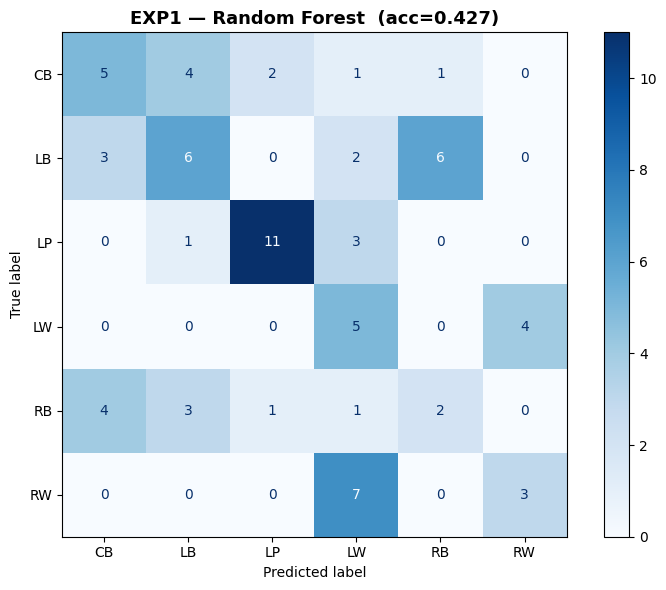

Guardada: position_output/exp1/cm_random_forest.png


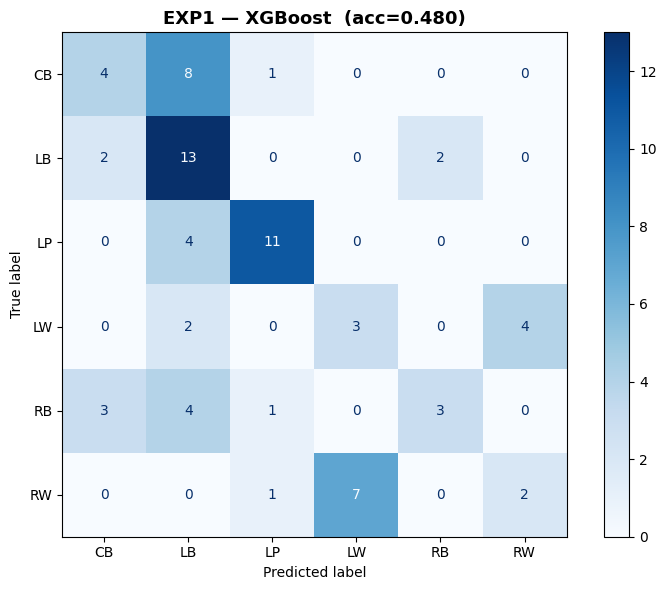

Guardada: position_output/exp1/cm_xgboost.png


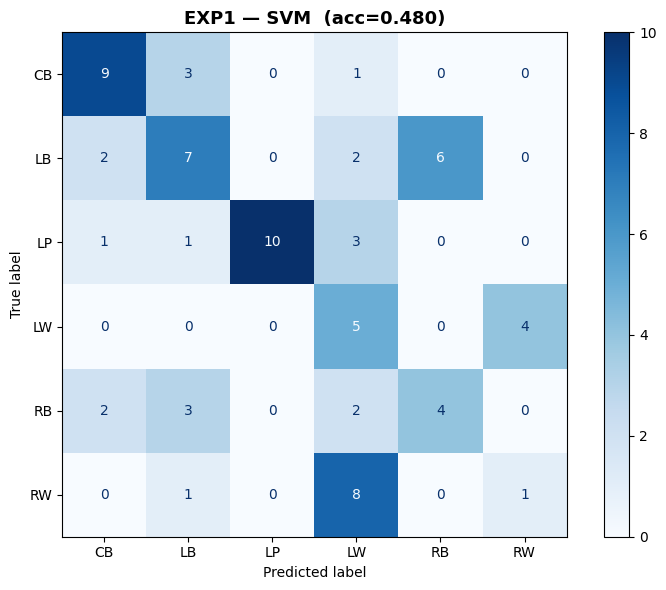

Guardada: position_output/exp1/cm_svm.png


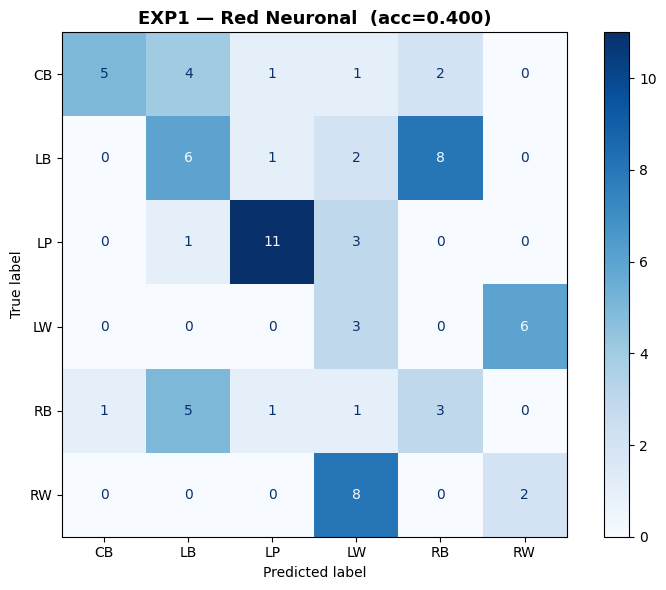

Guardada: position_output/exp1/cm_red_neuronal.png


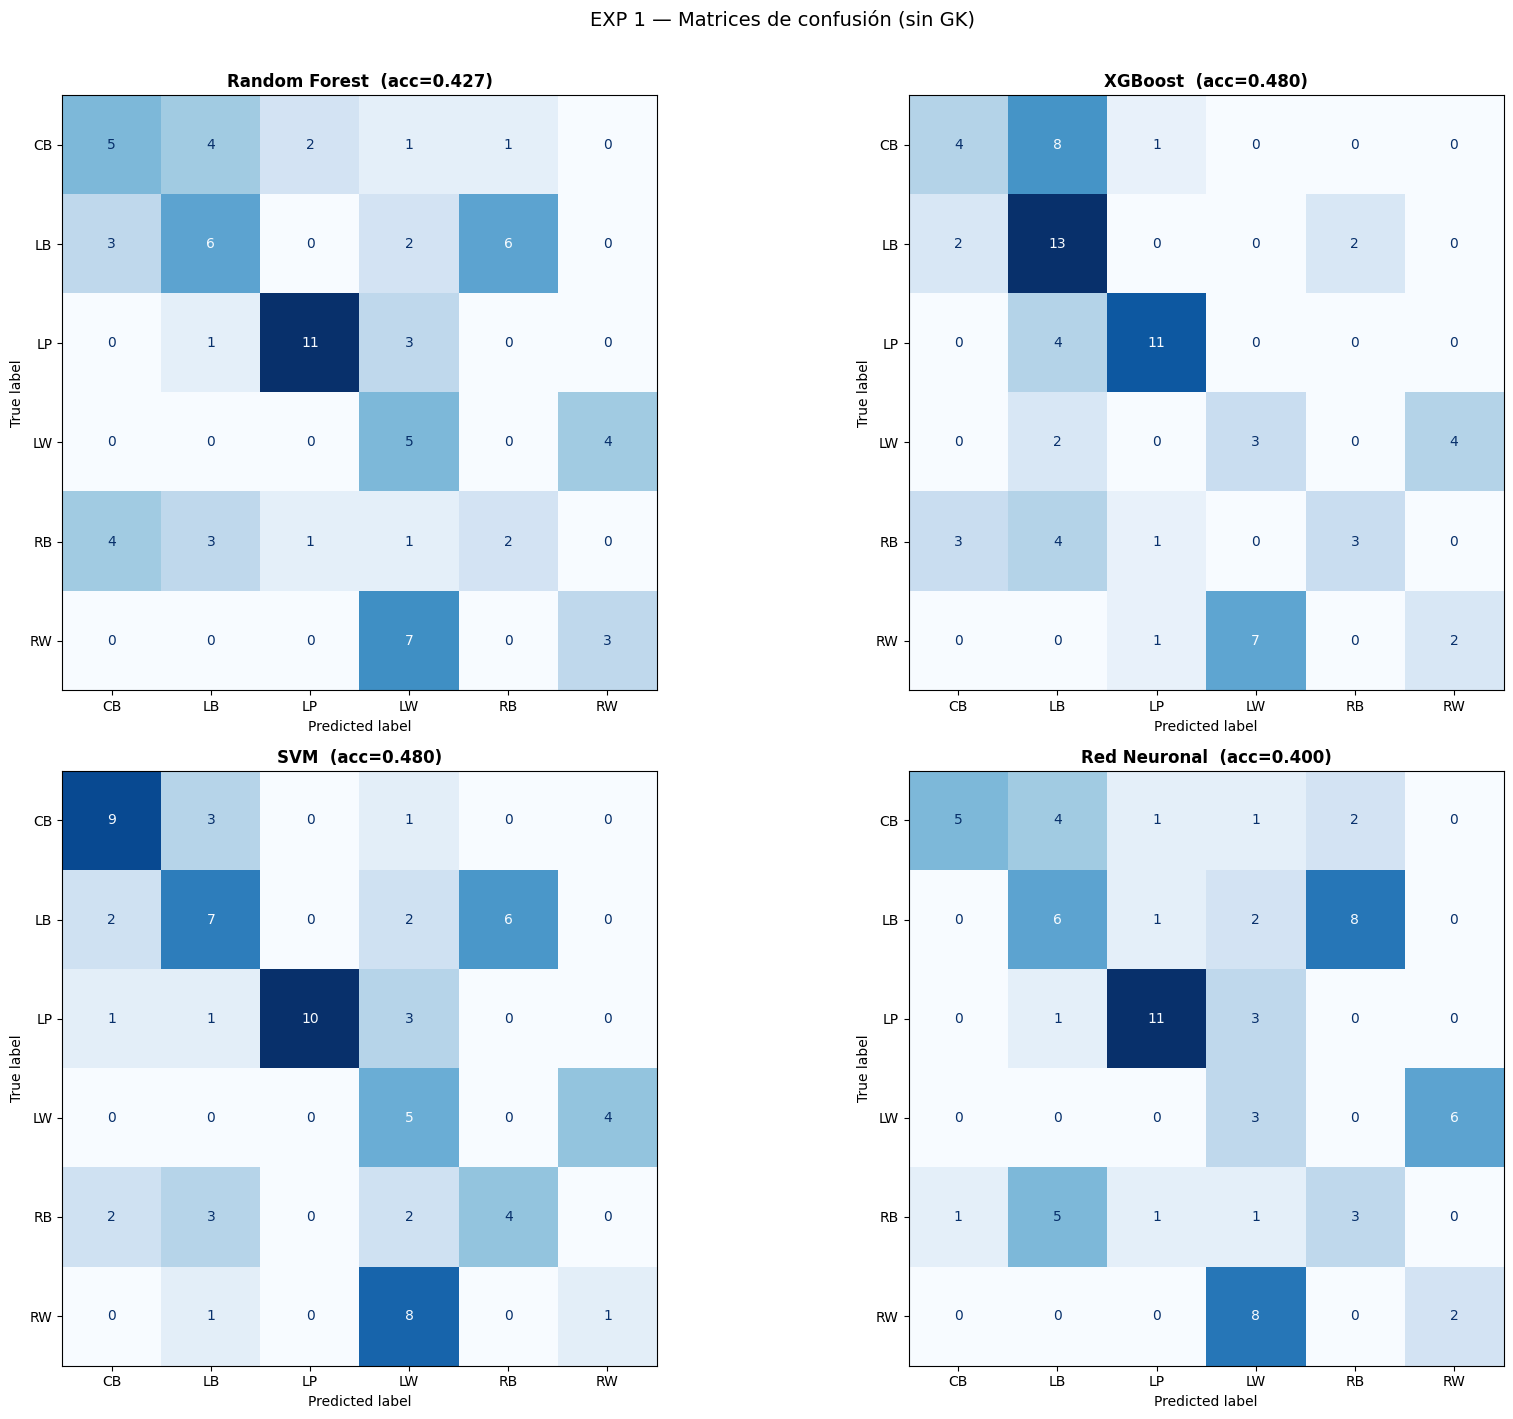

Guardada figura combinada: position_output/exp1/confusion_matrices_all.png


In [10]:
models_exp1 = [
    ('Random Forest', y1_pred_rf),
    ('XGBoost',       y1_pred_xgb),
    ('SVM',           y1_pred_svm),
    ('Red Neuronal',  y1_pred_mlp),
]

for name, preds in models_exp1:
    path = f"{OUT_ROOT}/exp1/cm_{name.replace(' ','_').lower()}.png"
    save_confusion_matrix(y1_test, preds, le1, f'EXP1 — {name}', path)

# Figura combinada de las 4 matrices
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()
for ax, (name, preds) in zip(axes, models_exp1):
    cm = confusion_matrix(y1_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=le1.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y1_test, preds)
    ax.set_title(f'{name}  (acc={acc:.3f})', fontsize=12, fontweight='bold')
plt.suptitle('EXP 1 — Matrices de confusión (sin GK)', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp1/confusion_matrices_all.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Guardada figura combinada: {OUT_ROOT}/exp1/confusion_matrices_all.png")

### 1.8 Tabla de métricas — EXP 1

In [11]:
train_accs1 = [train_acc_rf1, train_acc_xgb1, train_acc_svm1, train_acc_mlp1]
cvs1 = [
    (cv_rf1.mean(),  cv_rf1.std()),
    (cv_xgb1.mean(), cv_xgb1.std()),
    (cv_svm1.mean(), cv_svm1.std()),
    (cv_mlp1.mean(), cv_mlp1.std()),
]

rows_exp1 = []
for (name, preds), (cv_m, cv_s), tr_acc in zip(models_exp1, cvs1, train_accs1):
    rows_exp1.append(metrics_table(y1_test, preds, le1, name, cv_m, cv_s, tr_acc))

df_metrics_exp1 = pd.DataFrame(rows_exp1).set_index('Modelo')
# Reordenar columnas para lectura intuitiva
col_order1 = ['Train Accuracy', 'CV Accuracy (mean)', 'CV Accuracy (std)',
              'Accuracy', 'Diferencia (Train-CV)', 'F1 (weighted)', 'F1 (macro)',
              'Precision (weighted)', 'Recall (weighted)']
df_metrics_exp1 = df_metrics_exp1[[c for c in col_order1 if c in df_metrics_exp1.columns]]
print('=== EXP 1 — Métricas globales (con Comprobación de sobreajuste) ===')
display(df_metrics_exp1.style.background_gradient(subset=['Diferencia (Train-CV)'], cmap='RdYlGn_r'))
df_metrics_exp1.to_csv(f'{OUT_ROOT}/exp1/metrics_global.csv')

# Tabla por clase
rows_class_exp1 = []
for name, preds in models_exp1:
    rows_class_exp1.extend(per_class_table(y1_test, preds, le1, name))
df_class_exp1 = pd.DataFrame(rows_class_exp1)
print('\n=== EXP 1 — Métricas por clase ===')
display(df_class_exp1)
df_class_exp1.to_csv(f'{OUT_ROOT}/exp1/metrics_per_class.csv', index=False)


=== EXP 1 — Métricas globales (con Comprobación de sobreajuste) ===


,Train Accuracy,CV Accuracy (mean),CV Accuracy (std),Accuracy,Diferencia (Train-CV),F1 (weighted),F1 (macro),Precision (weighted),Recall (weighted)
Modelo,,,,,,,,,
Random Forest,0.793900,0.506700,0.027500,0.426700,0.287200,0.428000,0.409300,0.447800,0.426700
XGBoost,0.895300,0.479700,0.033700,0.480000,0.415600,0.463800,0.434100,0.497700,0.480000
SVM,0.675700,0.500300,0.053200,0.480000,0.175400,0.488400,0.458600,0.531100,0.480000
Red Neuronal,0.770300,0.486700,0.046300,0.400000,0.283600,0.418300,0.390500,0.473800,0.400000



=== EXP 1 — Métricas por clase ===


,Modelo,Clase,Precision,Recall,F1-score
0,Random Forest,CB,0.4167,0.3846,0.4000
1,Random Forest,LB,0.4286,0.3529,0.3871
2,Random Forest,LP,0.7857,0.7333,0.7586
3,Random Forest,LW,0.2632,0.5556,0.3571
4,Random Forest,RB,0.2222,0.1818,0.2000
5,Random Forest,RW,0.4286,0.3000,0.3529
6,XGBoost,CB,0.4444,0.3077,0.3636
7,XGBoost,LB,0.4194,0.7647,0.5417
8,XGBoost,LP,0.7857,0.7333,0.7586
9,XGBoost,LW,0.3000,0.3333,0.3158


### 1.10 Comprobacion de sobreajuste — EXP 1

Comparamos **Train Accuracy**, **CV Accuracy (5-fold sobre train)** y **Test Accuracy** para detectar sobreajuste:

| Indicador | Señal |
|-----------|-------|
| Train >> CV ≈ Test | Sobreajuste claro |
| Train ≈ CV ≈ Test | Buen ajuste |
| Todos bajos | Infraajuste |

Se añaden también las **curvas de aprendizaje** para ver cómo evoluciona la brecha al variar el tamaño de entrenamiento.

=== EXP 1 — Comprobación de sobreajuste ===


,Train Accuracy,CV Accuracy (mean),CV Std (±),Test Accuracy,Diferencia Train-CV,Diferencia Train-Test
Modelo,,,,,,
Random Forest,0.793900,0.506700,0.027500,0.426700,0.287200,0.367300
XGBoost,0.895300,0.479700,0.033700,0.480000,0.415600,0.415300
SVM,0.675700,0.500300,0.053200,0.480000,0.175400,0.195700
Red Neuronal,0.770300,0.486700,0.046300,0.400000,0.283600,0.370300


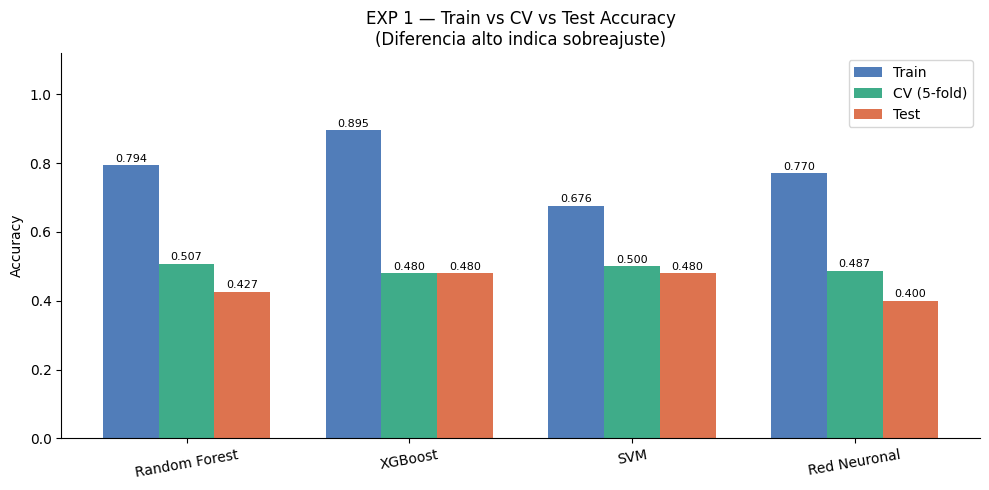

✓ Guardada: position_output/exp1/overfit_train_cv_test.png


In [12]:
from sklearn.model_selection import learning_curve

# ── Tabla resumen Train / CV / Test ─────────────────────────
models_exp1_dict = {
    'Random Forest': (rf1,  train_acc_rf1,  cv_rf1,  y1_pred_rf),
    'XGBoost':       (xgb1, train_acc_xgb1, cv_xgb1, y1_pred_xgb),
    'SVM':           (svm1, train_acc_svm1, cv_svm1, y1_pred_svm),
    'Red Neuronal':  (mlp1, train_acc_mlp1, cv_mlp1, y1_pred_mlp),
}

overfit_rows1 = []
for mname, (model, tr_acc, cv_scores, preds) in models_exp1_dict.items():
    test_acc = accuracy_score(y1_test, preds)
    overfit_rows1.append({
        'Modelo':            mname,
        'Train Accuracy':    round(tr_acc, 4),
        'CV Accuracy (mean)':round(cv_scores.mean(), 4),
        'CV Std (±)':        round(cv_scores.std(), 4),
        'Test Accuracy':     round(test_acc, 4),
        'Diferencia Train-CV':      round(tr_acc - cv_scores.mean(), 4),
        'Diferencia Train-Test':    round(tr_acc - test_acc, 4),
    })

df_overfit1 = pd.DataFrame(overfit_rows1).set_index('Modelo')
print('=== EXP 1 — Comprobación de sobreajuste ===')
display(df_overfit1.style.background_gradient(subset=['Diferencia Train-CV', 'Diferencia Train-Test'],
                                               cmap='RdYlGn_r'))
df_overfit1.to_csv(f'{OUT_ROOT}/exp1/overfit_diagnosis.csv')

# ── Gráfico: Train vs CV vs Test Accuracy ───────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x      = np.arange(len(overfit_rows1))
width  = 0.25
names  = [r['Modelo'] for r in overfit_rows1]
tr_vals  = [r['Train Accuracy']     for r in overfit_rows1]
cv_vals  = [r['CV Accuracy (mean)'] for r in overfit_rows1]
te_vals  = [r['Test Accuracy']      for r in overfit_rows1]

b1 = ax.bar(x - width, tr_vals, width, label='Train',         color='#3266ad', alpha=0.85)
b2 = ax.bar(x,         cv_vals, width, label='CV (5-fold)',   color='#1d9e75', alpha=0.85)
b3 = ax.bar(x + width, te_vals, width, label='Test',          color='#d85a30', alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Accuracy')
ax.set_title('EXP 1 — Train vs CV vs Test Accuracy\n(Diferencia alto indica sobreajuste)', fontsize=12)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp1/overfit_train_cv_test.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'✓ Guardada: {OUT_ROOT}/exp1/overfit_train_cv_test.png')


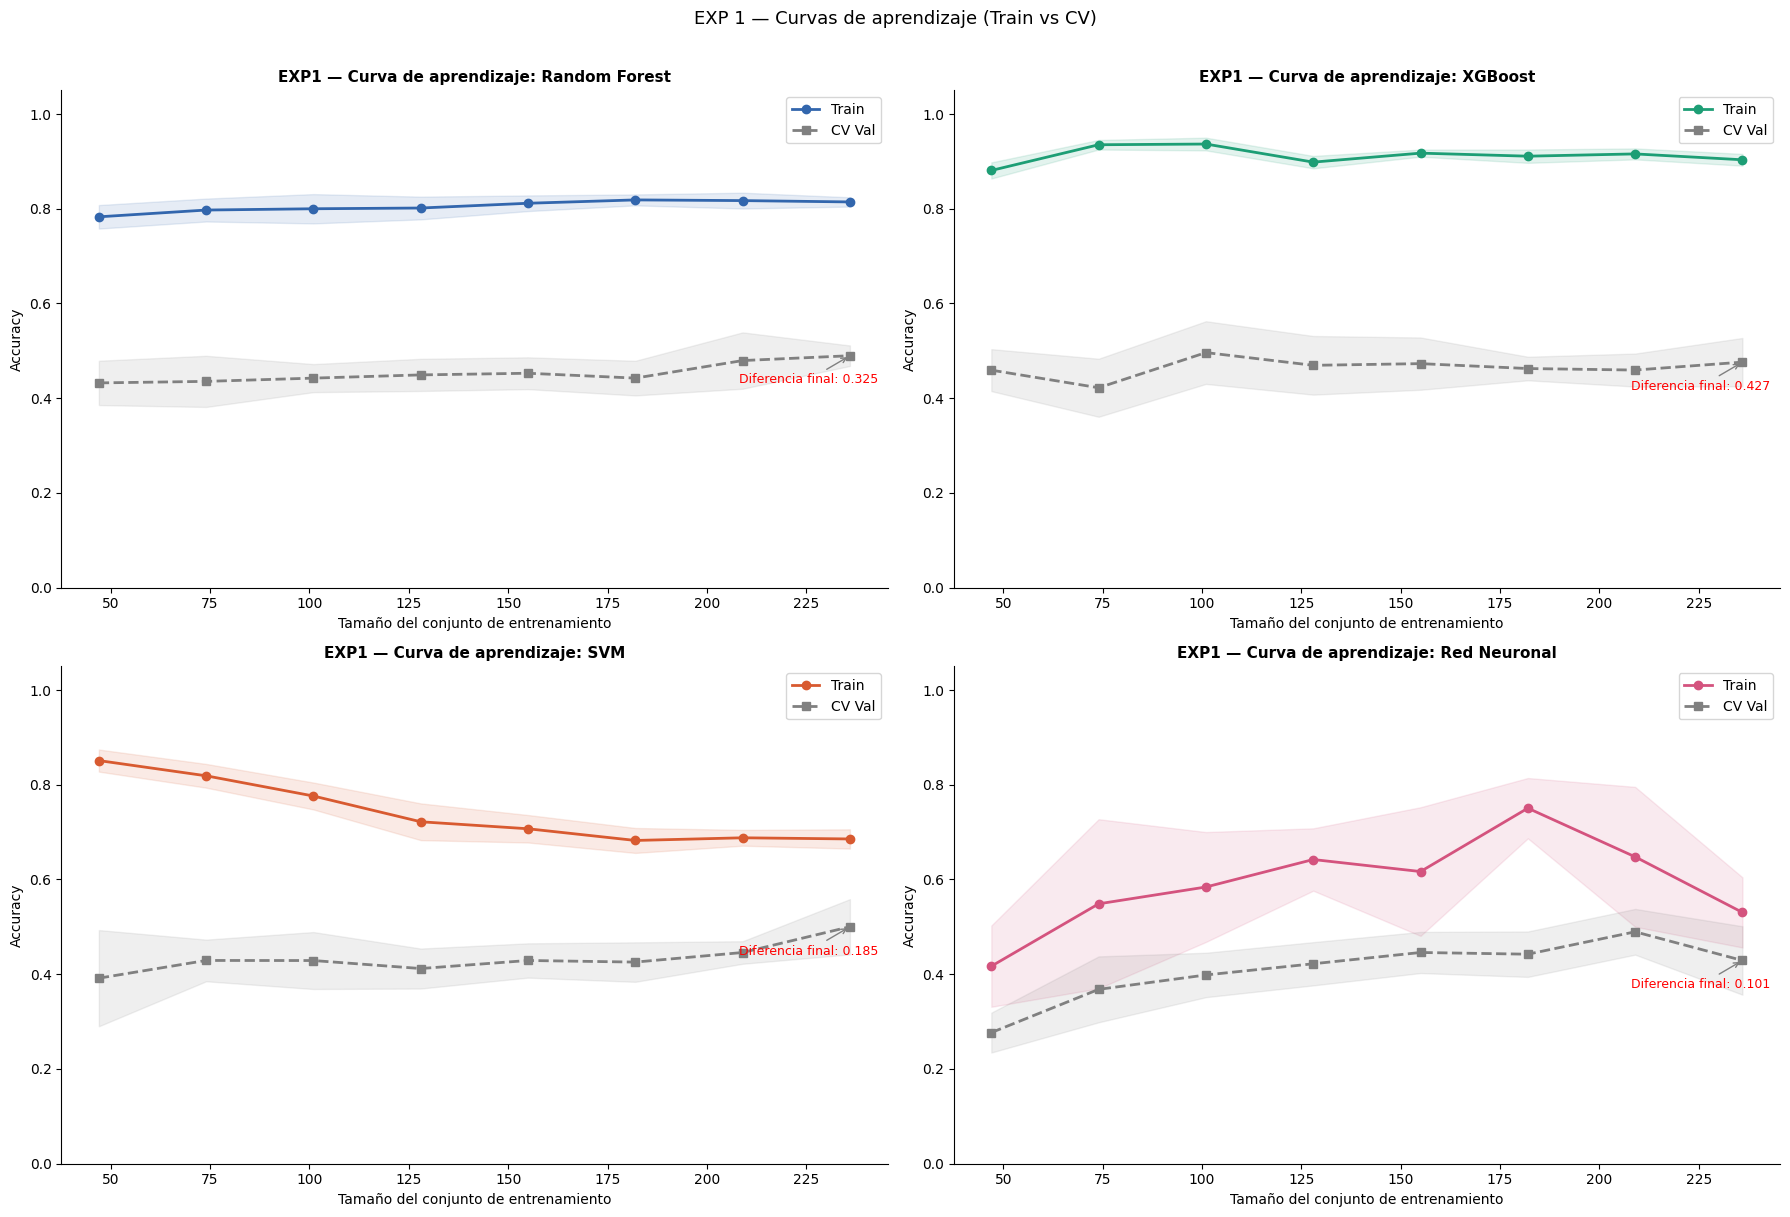

✓ Guardada: position_output/exp1/learning_curves.png


In [13]:
# ── Curvas de aprendizaje — EXP 1 ───────────────────────────
lc_models1 = [
    ('Random Forest', rf1,  '#3266ad'),
    ('XGBoost',       xgb1, '#1d9e75'),
    ('SVM',           svm1, '#d85a30'),
    ('Red Neuronal',  mlp1, '#d4537e'),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, (mname, model, color) in zip(axes, lc_models1):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X1_train_sc, y1_train,
        cv=cv5, scoring='accuracy',
        train_sizes=np.linspace(0.2, 1.0, 8),
        n_jobs=-1
    )
    tr_mean  = train_scores.mean(axis=1)
    tr_std   = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std  = val_scores.std(axis=1)

    ax.plot(train_sizes, tr_mean,  'o-', color=color,   label='Train',   linewidth=2)
    ax.plot(train_sizes, val_mean, 's--', color='gray', label='CV Val',  linewidth=2)
    ax.fill_between(train_sizes, tr_mean - tr_std,  tr_mean + tr_std,  alpha=0.12, color=color)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.12, color='gray')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'EXP1 — Curva de aprendizaje: {mname}', fontsize=11, fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.spines[['top', 'right']].set_visible(False)
    # Anotar Diferencia final
    Diferencia = tr_mean[-1] - val_mean[-1]
    ax.annotate(f'Diferencia final: {Diferencia:.3f}',
                xy=(train_sizes[-1], val_mean[-1]),
                xytext=(-80, -20), textcoords='offset points',
                fontsize=9, color='red' if Diferencia > 0.10 else 'green',
                arrowprops=dict(arrowstyle='->', color='gray'))

plt.suptitle('EXP 1 — Curvas de aprendizaje (Train vs CV)', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp1/learning_curves.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'✓ Guardada: {OUT_ROOT}/exp1/learning_curves.png')


### 1.9 Análisis SHAP — EXP 1 (mejor modelo)

Mejor modelo EXP1: XGBoost  (0.4800)


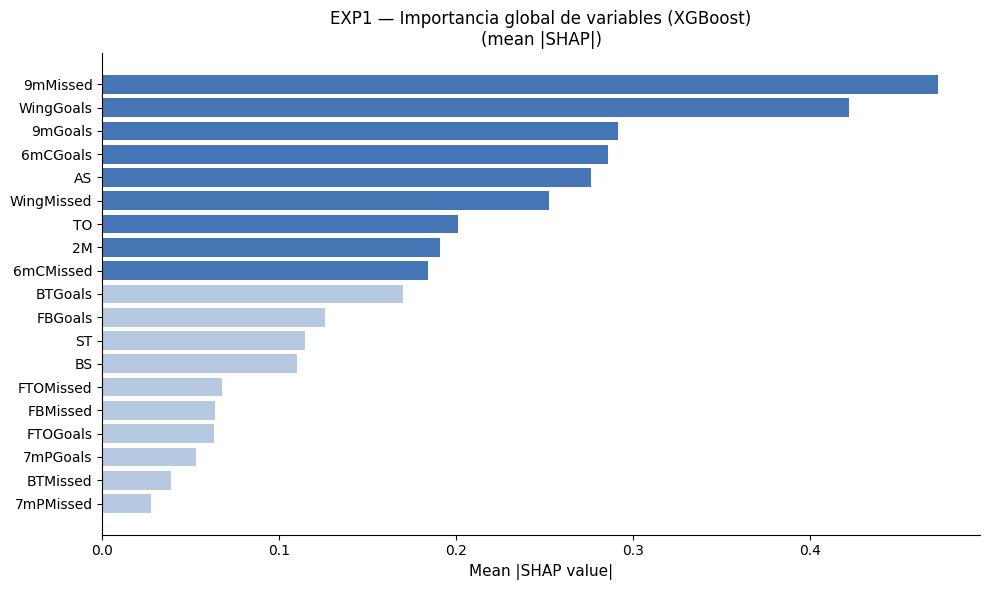


Top 10 variables más importantes (EXP1):


,mean_abs_shap
9mMissed,0.4724
WingGoals,0.4222
9mGoals,0.2913
6mCGoals,0.2860
AS,0.2761
WingMissed,0.2524
TO,0.2010
2M,0.1906
6mCMissed,0.1839
BTGoals,0.1698


In [14]:
# Elegir el mejor modelo por test accuracy
accs1 = {name: accuracy_score(y1_test, p) for name, p in models_exp1}
best_name1 = max(accs1, key=accs1.get)
best_model1_map = {
    'Random Forest': rf1,
    'XGBoost':       xgb1,
}
print(f'Mejor modelo EXP1: {best_name1}  ({accs1[best_name1]:.4f})')

# SHAP solo disponible directamente para modelos de árbol
shap_model1_name = best_name1 if best_name1 in best_model1_map else 'XGBoost'
shap_model1 = best_model1_map[shap_model1_name]

X1_all_sc = scaler1.transform(X1)
explainer1 = shap.TreeExplainer(shap_model1)
shap_vals1 = explainer1.shap_values(X1_all_sc)

# Importancia global
if isinstance(shap_vals1, list):
    global_shap1 = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals1], axis=0)
else:
    global_shap1 = np.abs(shap_vals1).mean(axis=(0, 2)) if shap_vals1.ndim == 3 else np.abs(shap_vals1).mean(axis=0)

shap_imp1 = pd.Series(global_shap1, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#3266ad' if v > shap_imp1.median() else '#b0c4de' for v in shap_imp1.values]
ax.barh(shap_imp1.index[::-1], shap_imp1.values[::-1], color=colors_bar[::-1], alpha=0.9)
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title(f'EXP1 — Importancia global de variables ({shap_model1_name})\n(mean |SHAP|)', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp1/shap_global_importance.png', dpi=130, bbox_inches='tight')
plt.show()
print('\nTop 10 variables más importantes (EXP1):')
display(shap_imp1.head(10).to_frame('mean_abs_shap').round(4))

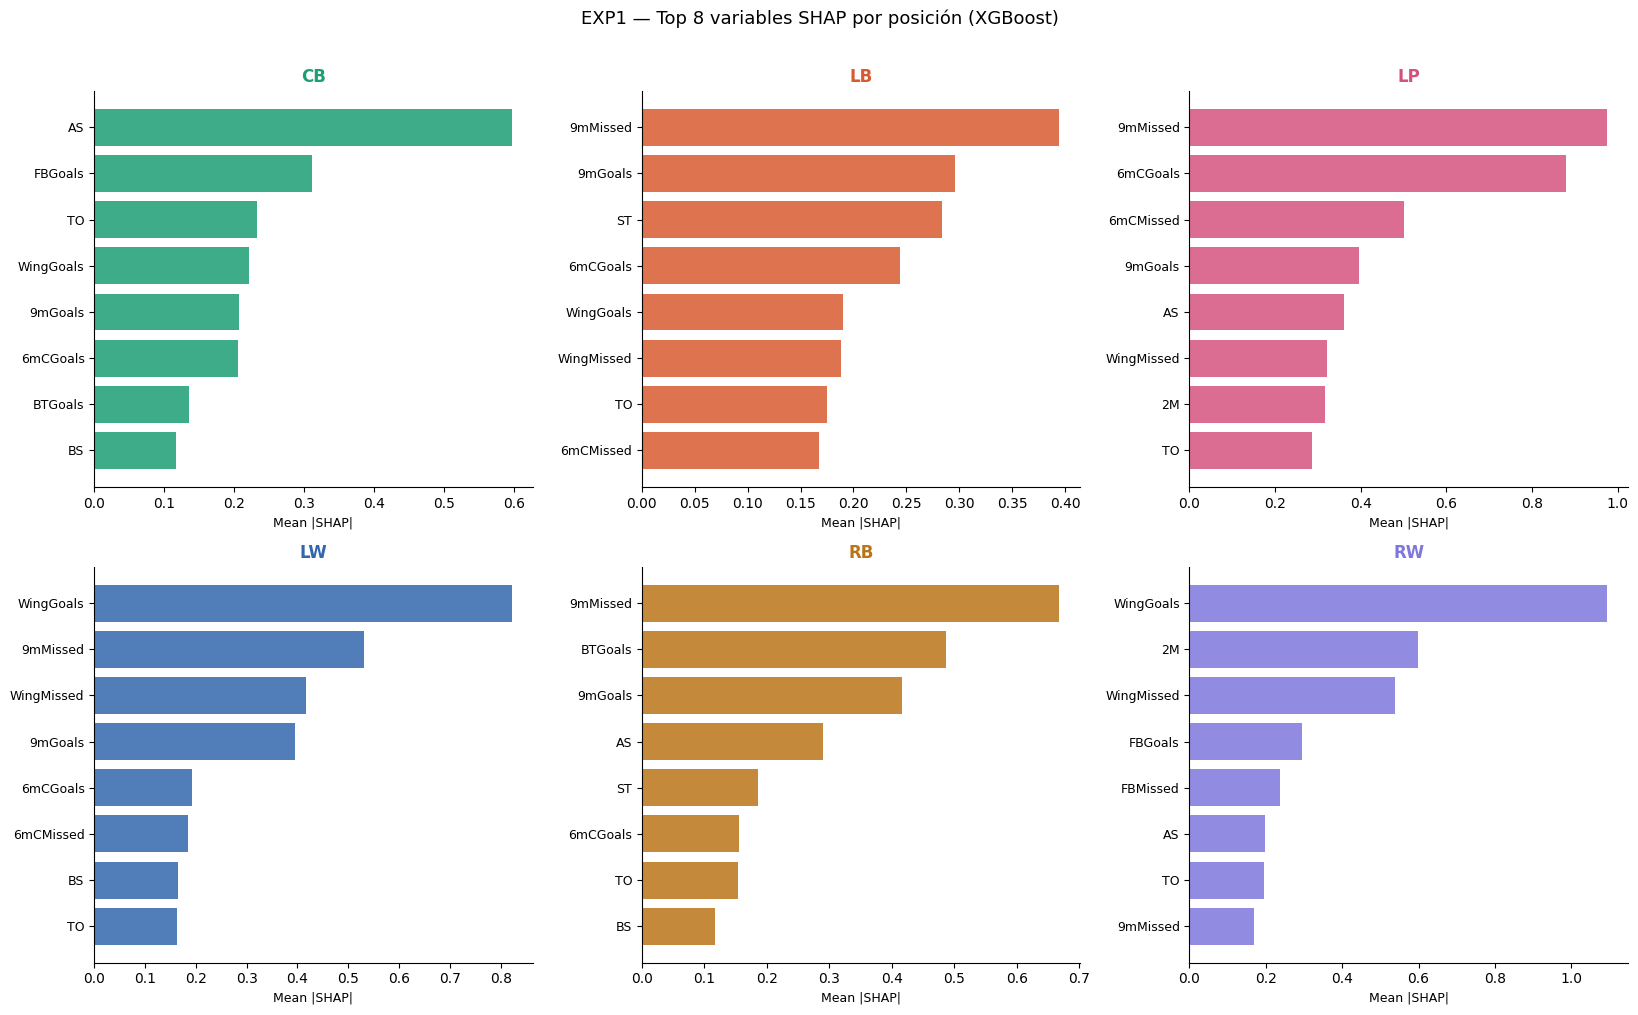

✓ Guardada: position_output/exp1/shap_per_position.png


In [15]:
# SHAP por posición — EXP1
if isinstance(shap_vals1, list):
    shap_list1 = shap_vals1
elif shap_vals1.ndim == 3:
    shap_list1 = [shap_vals1[:, :, i] for i in range(shap_vals1.shape[2])]
else:
    shap_list1 = [shap_vals1]

classes1 = le1.classes_
TOP_N = 8
n_cls1 = len(classes1)
n_cols1 = min(n_cls1, 3)
n_rows1 = math.ceil(n_cls1 / n_cols1)

fig, axes = plt.subplots(n_rows1, n_cols1, figsize=(n_cols1*5.5, n_rows1*5))
axes = np.array(axes).flatten()

for idx, cls in enumerate(classes1):
    sv = shap_list1[idx]
    mean_abs = np.abs(sv).mean(axis=0)
    importance = pd.Series(mean_abs, index=FEATURE_COLS).sort_values(ascending=False)
    top_vars = importance.head(TOP_N)
    color = POS_COLORS.get(cls, '#888')
    ax = axes[idx]
    ax.barh(range(TOP_N), top_vars.values[::-1], color=color, alpha=0.85)
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_vars.index[::-1], fontsize=9)
    ax.set_xlabel('Mean |SHAP|', fontsize=9)
    ax.set_title(f'{cls}', fontsize=12, fontweight='bold', color=color)
    ax.spines[['top', 'right']].set_visible(False)

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f'EXP1 — Top {TOP_N} variables SHAP por posición ({shap_model1_name})',
             fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp1/shap_per_position.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Guardada: {OUT_ROOT}/exp1/shap_per_position.png')

---

# ══════════════════════════════════════════
# EXPERIMENTO 2 — Posiciones agrupadas 
# LW+RW → Wing | LB+RB → Lateral | CB → Central | LP → Pivote
# (4 clases)
# ══════════════════════════════════════════

In [16]:
# ── Mapeo de posiciones equivalentes ────────────────────────
POS_MAP = {
    'LW': 'Wing',    'RW': 'Wing',
    'LB': 'Lateral', 'RB': 'Lateral',
    'CB': 'Central',
    'LP': 'Pivote',
}

df_exp2 = df_full[df_full[TARGET_COL] != 'GK'].copy()
df_exp2['Grupo'] = df_exp2[TARGET_COL].map(POS_MAP)

print('[EXP 2] Distribución de grupos:')
print(df_exp2['Grupo'].value_counts())

X2 = df_exp2[FEATURE_COLS].values
y2_raw = df_exp2['Grupo'].values

le2 = LabelEncoder()
y2 = le2.fit_transform(y2_raw)
print('\nClases EXP 2:', le2.classes_)

[EXP 2] Distribución de grupos:
Grupo
Lateral    139
Wing        96
Pivote      72
Central     64
Name: count, dtype: int64

Clases EXP 2: ['Central' 'Lateral' 'Pivote' 'Wing']


### 2.1 Split 80/20 estratificado + Estandarización z-score

In [17]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_STATE, stratify=y2
)

scaler2 = StandardScaler()              # z-score
X2_train_sc = scaler2.fit_transform(X2_train)   # fit SOLO en train
X2_test_sc  = scaler2.transform(X2_test)        # transform en test

print(f'Train: {X2_train_sc.shape[0]}  |  Test: {X2_test_sc.shape[0]}')

Train: 296  |  Test: 75


### 2.2 Random Forest + GridSearchCV

In [18]:
gs_rf2 = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    param_grid_rf, cv=cv5, scoring='accuracy', n_jobs=-1, verbose=0
)
gs_rf2.fit(X2_train_sc, y2_train)
rf2 = gs_rf2.best_estimator_

print(f'[EXP2 RF] Mejores hiperparámetros: {gs_rf2.best_params_}')
y2_pred_rf = rf2.predict(X2_test_sc)
train_acc_rf2 = accuracy_score(y2_train, rf2.predict(X2_train_sc))
cv_rf2 = cross_val_score(rf2, X2_train_sc, y2_train, cv=cv5, scoring='accuracy')
print(f'[EXP2 RF] Train accuracy: {train_acc_rf2:.4f}')
print(f'[EXP2 RF] Test accuracy:  {accuracy_score(y2_test, y2_pred_rf):.4f}')
print(f'[EXP2 RF] Diferencia Train-Test: {train_acc_rf2 - accuracy_score(y2_test, y2_pred_rf):.4f}')
print(classification_report(y2_test, y2_pred_rf, target_names=le2.classes_))

[EXP2 RF] Mejores hiperparámetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 300}
[EXP2 RF] Train accuracy: 0.9527
[EXP2 RF] Test accuracy:  0.7467
[EXP2 RF] Diferencia Train-Test: 0.2060
              precision    recall  f1-score   support

     Central       0.60      0.46      0.52        13
     Lateral       0.76      0.79      0.77        28
      Pivote       0.75      0.80      0.77        15
        Wing       0.80      0.84      0.82        19

    accuracy                           0.75        75
   macro avg       0.73      0.72      0.72        75
weighted avg       0.74      0.75      0.74        75



### 2.3 XGBoost + GridSearchCV

In [19]:
gs_xgb2 = GridSearchCV(
    xgb.XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    param_grid_xgb, cv=cv5, scoring='accuracy', n_jobs=-1, verbose=0
)
gs_xgb2.fit(X2_train_sc, y2_train)
xgb2 = gs_xgb2.best_estimator_

print(f'[EXP2 XGB] Mejores hiperparámetros: {gs_xgb2.best_params_}')
y2_pred_xgb = xgb2.predict(X2_test_sc)
train_acc_xgb2 = accuracy_score(y2_train, xgb2.predict(X2_train_sc))
cv_xgb2 = cross_val_score(xgb2, X2_train_sc, y2_train, cv=cv5, scoring='accuracy')
print(f'[EXP2 XGB] Train accuracy: {train_acc_xgb2:.4f}')
print(f'[EXP2 XGB] Test accuracy:  {accuracy_score(y2_test, y2_pred_xgb):.4f}')
print(f'[EXP2 XGB] Diferencia Train-Test: {train_acc_xgb2 - accuracy_score(y2_test, y2_pred_xgb):.4f}')
print(classification_report(y2_test, y2_pred_xgb, target_names=le2.classes_))

[EXP2 XGB] Mejores hiperparámetros: {'colsample_bytree': 0.5, 'max_depth': 3, 'n_estimators': 200, 'reg_alpha': 1}
[EXP2 XGB] Train accuracy: 0.9223
[EXP2 XGB] Test accuracy:  0.7200
[EXP2 XGB] Diferencia Train-Test: 0.2023
              precision    recall  f1-score   support

     Central       0.50      0.31      0.38        13
     Lateral       0.66      0.82      0.73        28
      Pivote       0.86      0.80      0.83        15
        Wing       0.83      0.79      0.81        19

    accuracy                           0.72        75
   macro avg       0.71      0.68      0.69        75
weighted avg       0.71      0.72      0.71        75



### 2.4 SVM + GridSearchCV

In [20]:
gs_svm2 = GridSearchCV(
    SVC(class_weight='balanced', random_state=RANDOM_STATE, probability=True),
    param_grid_svm, cv=cv5, scoring='accuracy', n_jobs=-1, verbose=0
)
gs_svm2.fit(X2_train_sc, y2_train)
svm2 = gs_svm2.best_estimator_

print(f'[EXP2 SVM] Mejores hiperparámetros: {gs_svm2.best_params_}')
y2_pred_svm = svm2.predict(X2_test_sc)
train_acc_svm2 = accuracy_score(y2_train, svm2.predict(X2_train_sc))
cv_svm2 = cross_val_score(svm2, X2_train_sc, y2_train, cv=cv5, scoring='accuracy')
print(f'[EXP2 SVM] Train accuracy: {train_acc_svm2:.4f}')
print(f'[EXP2 SVM] Test accuracy:  {accuracy_score(y2_test, y2_pred_svm):.4f}')
print(f'[EXP2 SVM] Diferencia Train-Test: {train_acc_svm2 - accuracy_score(y2_test, y2_pred_svm):.4f}')
print(classification_report(y2_test, y2_pred_svm, target_names=le2.classes_))

[EXP2 SVM] Mejores hiperparámetros: {'C': 1.0, 'gamma': 'scale', 'kernel': 'linear'}
[EXP2 SVM] Train accuracy: 0.7838
[EXP2 SVM] Test accuracy:  0.6267
[EXP2 SVM] Diferencia Train-Test: 0.1571
              precision    recall  f1-score   support

     Central       0.38      0.69      0.49        13
     Lateral       0.83      0.36      0.50        28
      Pivote       0.71      0.80      0.75        15
        Wing       0.73      0.84      0.78        19

    accuracy                           0.63        75
   macro avg       0.66      0.67      0.63        75
weighted avg       0.70      0.63      0.62        75



### 2.5 Red Neuronal (MLP) + GridSearchCV

In [21]:
gs_mlp2 = GridSearchCV(
    MLPClassifier(max_iter=500, early_stopping=True, random_state=RANDOM_STATE),
    param_grid_mlp, cv=cv5, scoring='accuracy', n_jobs=-1, verbose=0
)
gs_mlp2.fit(X2_train_sc, y2_train)
mlp2 = gs_mlp2.best_estimator_

print(f'[EXP2 MLP] Mejores hiperparámetros: {gs_mlp2.best_params_}')
y2_pred_mlp = mlp2.predict(X2_test_sc)
train_acc_mlp2 = accuracy_score(y2_train, mlp2.predict(X2_train_sc))
cv_mlp2 = cross_val_score(mlp2, X2_train_sc, y2_train, cv=cv5, scoring='accuracy')
print(f'[EXP2 MLP] Train accuracy: {train_acc_mlp2:.4f}')
print(f'[EXP2 MLP] Test accuracy:  {accuracy_score(y2_test, y2_pred_mlp):.4f}')
print(f'[EXP2 MLP] Diferencia Train-Test: {train_acc_mlp2 - accuracy_score(y2_test, y2_pred_mlp):.4f}')
print(classification_report(y2_test, y2_pred_mlp, target_names=le2.classes_))

[EXP2 MLP] Mejores hiperparámetros: {'activation': 'relu', 'alpha': 0.0005, 'hidden_layer_sizes': (512, 256, 128, 64), 'learning_rate': 'adaptive', 'learning_rate_init': 0.0005}
[EXP2 MLP] Train accuracy: 0.7872
[EXP2 MLP] Test accuracy:  0.6933
[EXP2 MLP] Diferencia Train-Test: 0.0938
              precision    recall  f1-score   support

     Central       0.33      0.08      0.12        13
     Lateral       0.61      0.82      0.70        28
      Pivote       0.76      0.87      0.81        15
        Wing       0.88      0.79      0.83        19

    accuracy                           0.69        75
   macro avg       0.65      0.64      0.62        75
weighted avg       0.66      0.69      0.66        75



### 2.6 Matrices de confusión — EXP 2 (imágenes)

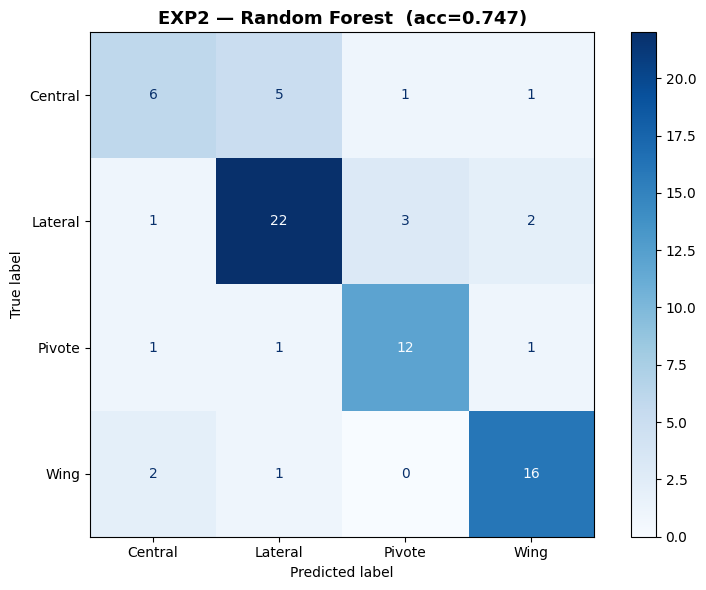

Guardada: position_output/exp2/cm_random_forest.png


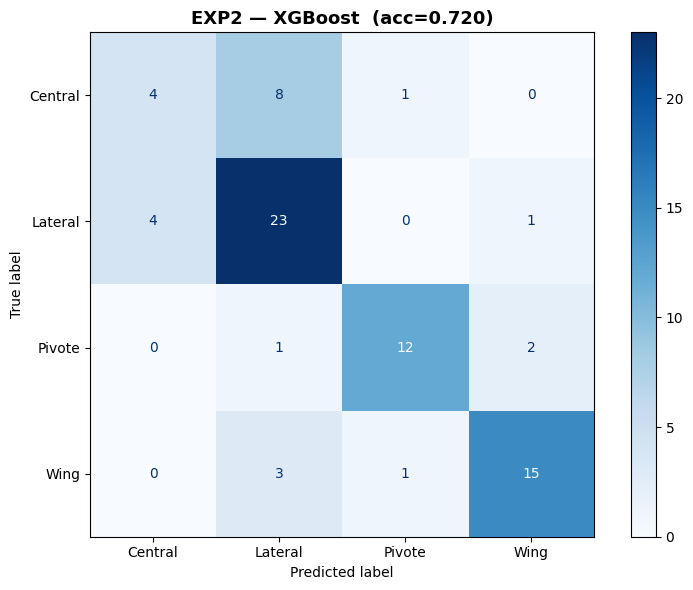

Guardada: position_output/exp2/cm_xgboost.png


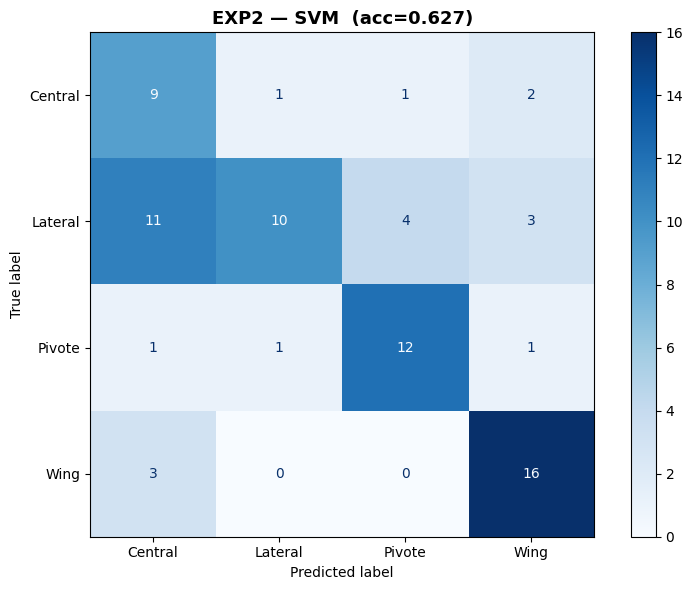

Guardada: position_output/exp2/cm_svm.png


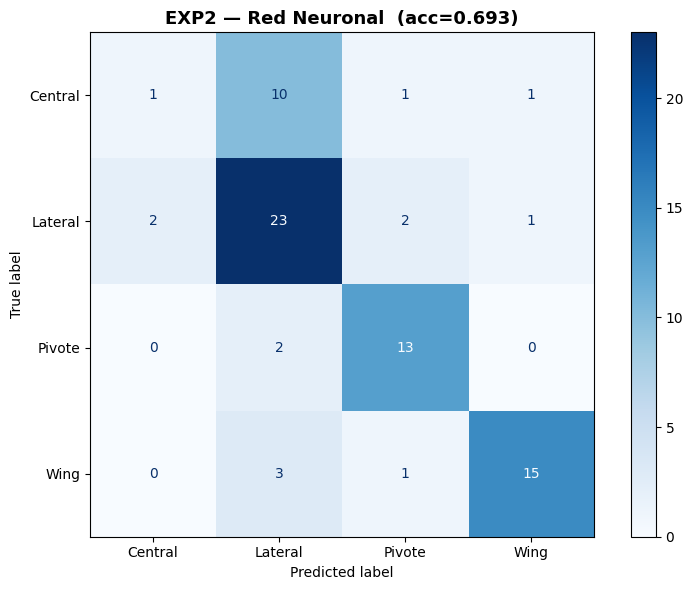

Guardada: position_output/exp2/cm_red_neuronal.png


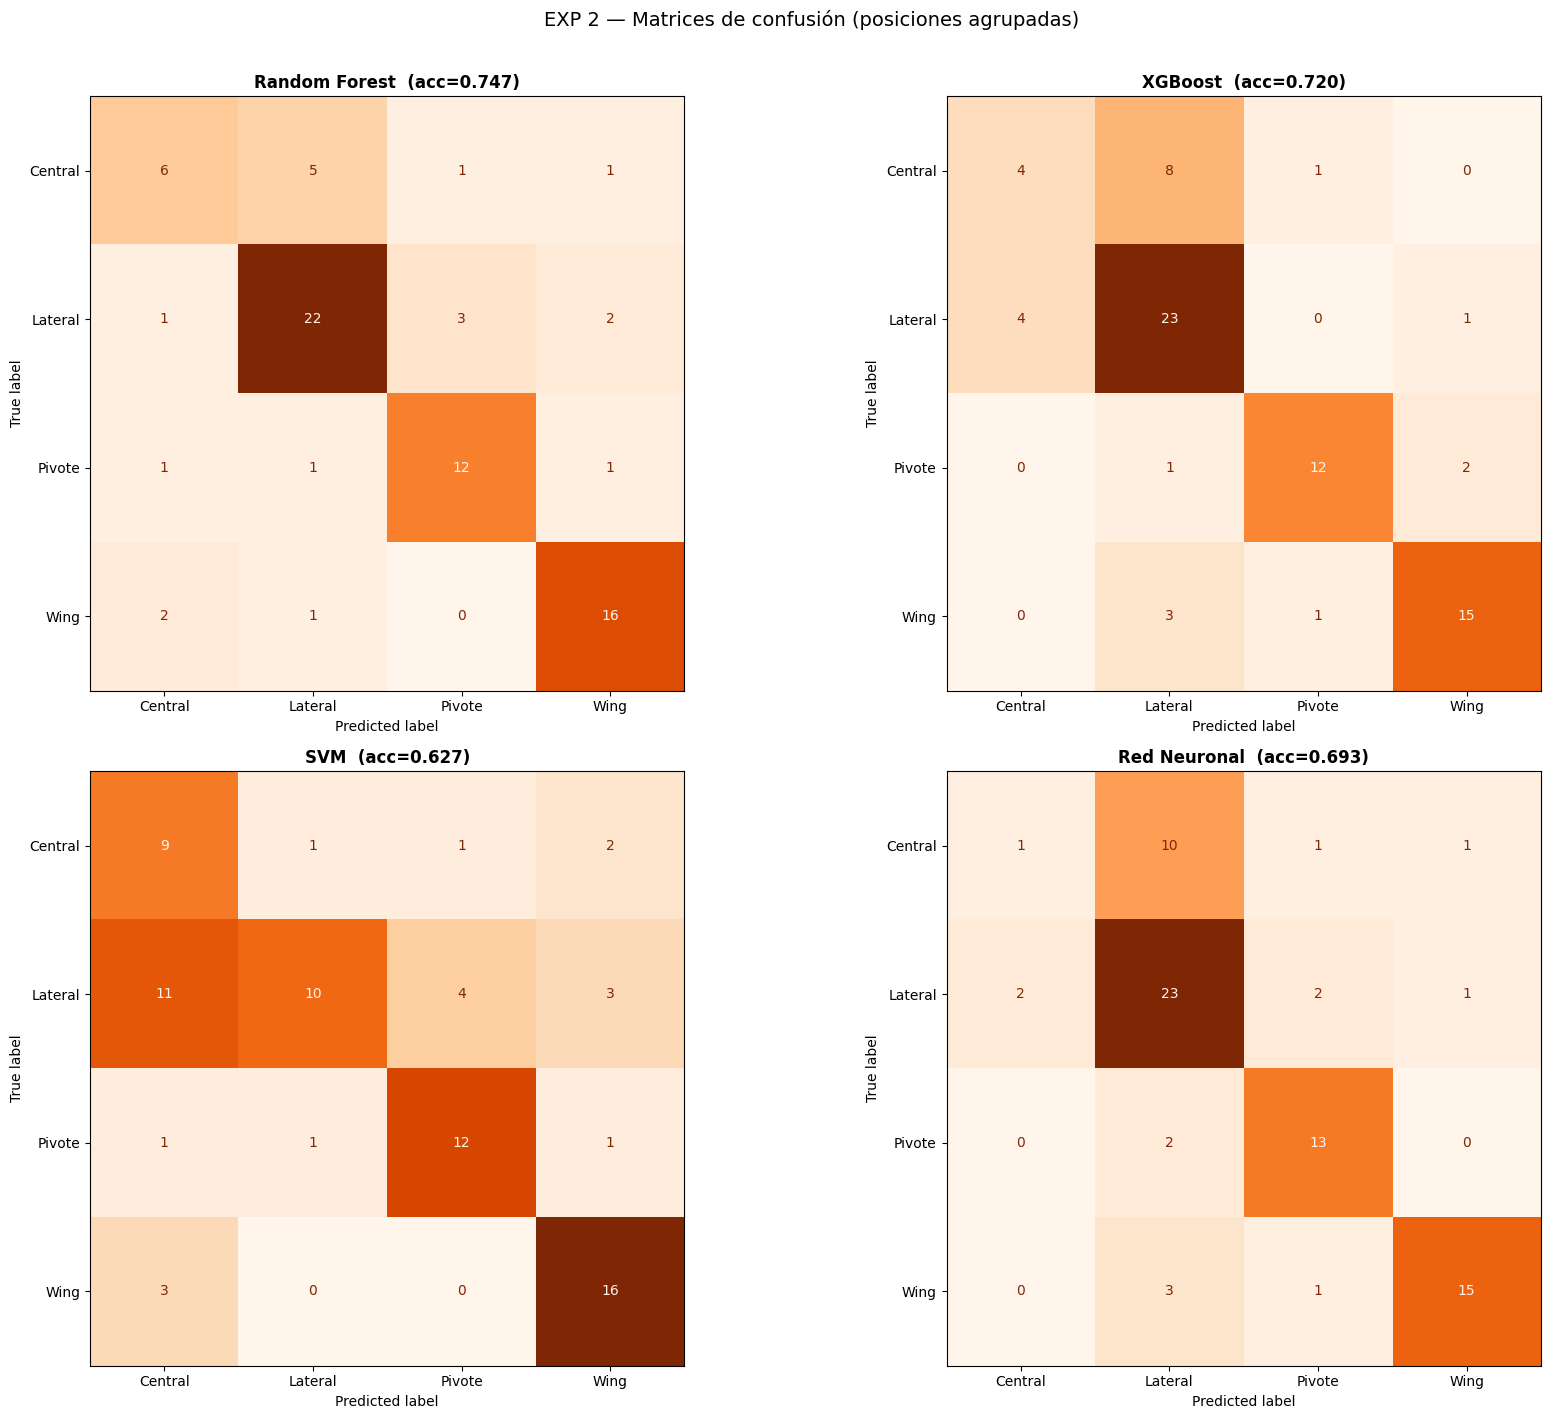

Guardada figura combinada: position_output/exp2/confusion_matrices_all.png


In [22]:
models_exp2 = [
    ('Random Forest', y2_pred_rf),
    ('XGBoost',       y2_pred_xgb),
    ('SVM',           y2_pred_svm),
    ('Red Neuronal',  y2_pred_mlp),
]

for name, preds in models_exp2:
    path = f"{OUT_ROOT}/exp2/cm_{name.replace(' ','_').lower()}.png"
    save_confusion_matrix(y2_test, preds, le2, f'EXP2 — {name}', path)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()
for ax, (name, preds) in zip(axes, models_exp2):
    cm = confusion_matrix(y2_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=le2.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Oranges')
    acc = accuracy_score(y2_test, preds)
    ax.set_title(f'{name}  (acc={acc:.3f})', fontsize=12, fontweight='bold')
plt.suptitle('EXP 2 — Matrices de confusión (posiciones agrupadas)', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp2/confusion_matrices_all.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Guardada figura combinada: {OUT_ROOT}/exp2/confusion_matrices_all.png")

### 2.7 Tabla de métricas — EXP 2

In [23]:
train_accs2 = [train_acc_rf2, train_acc_xgb2, train_acc_svm2, train_acc_mlp2]
cvs2 = [
    (cv_rf2.mean(),  cv_rf2.std()),
    (cv_xgb2.mean(), cv_xgb2.std()),
    (cv_svm2.mean(), cv_svm2.std()),
    (cv_mlp2.mean(), cv_mlp2.std()),
]

rows_exp2 = []
for (name, preds), (cv_m, cv_s), tr_acc in zip(models_exp2, cvs2, train_accs2):
    rows_exp2.append(metrics_table(y2_test, preds, le2, name, cv_m, cv_s, tr_acc))

df_metrics_exp2 = pd.DataFrame(rows_exp2).set_index('Modelo')
col_order2 = ['Train Accuracy', 'CV Accuracy (mean)', 'CV Accuracy (std)',
              'Accuracy', 'Diferencia (Train-CV)', 'F1 (weighted)', 'F1 (macro)',
              'Precision (weighted)', 'Recall (weighted)']
df_metrics_exp2 = df_metrics_exp2[[c for c in col_order2 if c in df_metrics_exp2.columns]]
print('=== EXP 2 — Métricas globales ===')
display(df_metrics_exp2.style.background_gradient(subset=['Diferencia (Train-CV)'], cmap='RdYlGn_r'))
df_metrics_exp2.to_csv(f'{OUT_ROOT}/exp2/metrics_global.csv')

rows_class_exp2 = []
for name, preds in models_exp2:
    rows_class_exp2.extend(per_class_table(y2_test, preds, le2, name))
df_class_exp2 = pd.DataFrame(rows_class_exp2)
print('\n=== EXP 2 — Métricas por clase ===')
display(df_class_exp2)
df_class_exp2.to_csv(f'{OUT_ROOT}/exp2/metrics_per_class.csv', index=False)


=== EXP 2 — Métricas globales ===


,Train Accuracy,CV Accuracy (mean),CV Accuracy (std),Accuracy,Diferencia (Train-CV),F1 (weighted),F1 (macro),Precision (weighted),Recall (weighted)
Modelo,,,,,,,,,
Random Forest,0.952700,0.719600,0.017000,0.746700,0.233100,0.741300,0.722100,0.739900,0.746700
XGBoost,0.922300,0.712900,0.046400,0.720000,0.209400,0.709500,0.687400,0.714500,0.720000
SVM,0.783800,0.665400,0.030700,0.626700,0.118400,0.618700,0.629200,0.701500,0.626700
Red Neuronal,0.787200,0.722900,0.041100,0.693300,0.064200,0.655500,0.617000,0.660200,0.693300



=== EXP 2 — Métricas por clase ===


,Modelo,Clase,Precision,Recall,F1-score
0,Random Forest,Central,0.6000,0.4615,0.5217
1,Random Forest,Lateral,0.7586,0.7857,0.7719
2,Random Forest,Pivote,0.7500,0.8000,0.7742
3,Random Forest,Wing,0.8000,0.8421,0.8205
4,XGBoost,Central,0.5000,0.3077,0.3810
5,XGBoost,Lateral,0.6571,0.8214,0.7302
6,XGBoost,Pivote,0.8571,0.8000,0.8276
7,XGBoost,Wing,0.8333,0.7895,0.8108
8,SVM,Central,0.3750,0.6923,0.4865
9,SVM,Lateral,0.8333,0.3571,0.5000


### 2.9 Comprobación de sobreajuste — EXP 2

Mismo análisis que en EXP 1: comparación Train / CV / Test y curvas de aprendizaje para los 4 modelos con posiciones agrupadas.

=== EXP 2 — Comprobación de sobreajuste ===


,Train Accuracy,CV Accuracy (mean),CV Std (±),Test Accuracy,Diferencia Train-CV,Diferencia Train-Test
Modelo,,,,,,
Random Forest,0.952700,0.719600,0.017000,0.746700,0.233100,0.206000
XGBoost,0.922300,0.712900,0.046400,0.720000,0.209400,0.202300
SVM,0.783800,0.665400,0.030700,0.626700,0.118400,0.157100
Red Neuronal,0.787200,0.722900,0.041100,0.693300,0.064200,0.093800


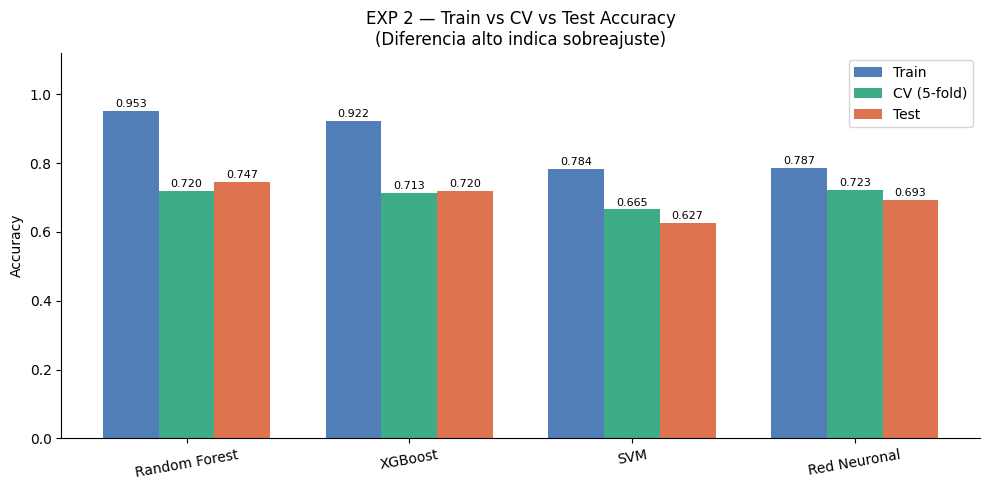

Guardada: position_output/exp2/overfit_train_cv_test.png


In [24]:
# ── Tabla resumen Train / CV / Test — EXP2 ──────────────────
models_exp2_dict = {
    'Random Forest': (rf2,  train_acc_rf2,  cv_rf2,  y2_pred_rf),
    'XGBoost':       (xgb2, train_acc_xgb2, cv_xgb2, y2_pred_xgb),
    'SVM':           (svm2, train_acc_svm2, cv_svm2, y2_pred_svm),
    'Red Neuronal':  (mlp2, train_acc_mlp2, cv_mlp2, y2_pred_mlp),
}

overfit_rows2 = []
for mname, (model, tr_acc, cv_scores, preds) in models_exp2_dict.items():
    test_acc = accuracy_score(y2_test, preds)
    overfit_rows2.append({
        'Modelo':            mname,
        'Train Accuracy':    round(tr_acc, 4),
        'CV Accuracy (mean)':round(cv_scores.mean(), 4),
        'CV Std (±)':        round(cv_scores.std(), 4),
        'Test Accuracy':     round(test_acc, 4),
        'Diferencia Train-CV':      round(tr_acc - cv_scores.mean(), 4),
        'Diferencia Train-Test':    round(tr_acc - test_acc, 4),
    })

df_overfit2 = pd.DataFrame(overfit_rows2).set_index('Modelo')
print('=== EXP 2 — Comprobación de sobreajuste ===')
display(df_overfit2.style.background_gradient(subset=['Diferencia Train-CV', 'Diferencia Train-Test'],
                                               cmap='RdYlGn_r'))
df_overfit2.to_csv(f'{OUT_ROOT}/exp2/overfit_diagnosis.csv')

# ── Gráfico: Train vs CV vs Test Accuracy — EXP2 ────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(overfit_rows2))
names2   = [r['Modelo'] for r in overfit_rows2]
tr_vals2 = [r['Train Accuracy']     for r in overfit_rows2]
cv_vals2 = [r['CV Accuracy (mean)'] for r in overfit_rows2]
te_vals2 = [r['Test Accuracy']      for r in overfit_rows2]

b1 = ax.bar(x - width, tr_vals2, width, label='Train',       color='#3266ad', alpha=0.85)
b2 = ax.bar(x,         cv_vals2, width, label='CV (5-fold)', color='#1d9e75', alpha=0.85)
b3 = ax.bar(x + width, te_vals2, width, label='Test',        color='#d85a30', alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(names2, rotation=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Accuracy')
ax.set_title('EXP 2 — Train vs CV vs Test Accuracy\n(Diferencia alto indica sobreajuste)', fontsize=12)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp2/overfit_train_cv_test.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Guardada: {OUT_ROOT}/exp2/overfit_train_cv_test.png')


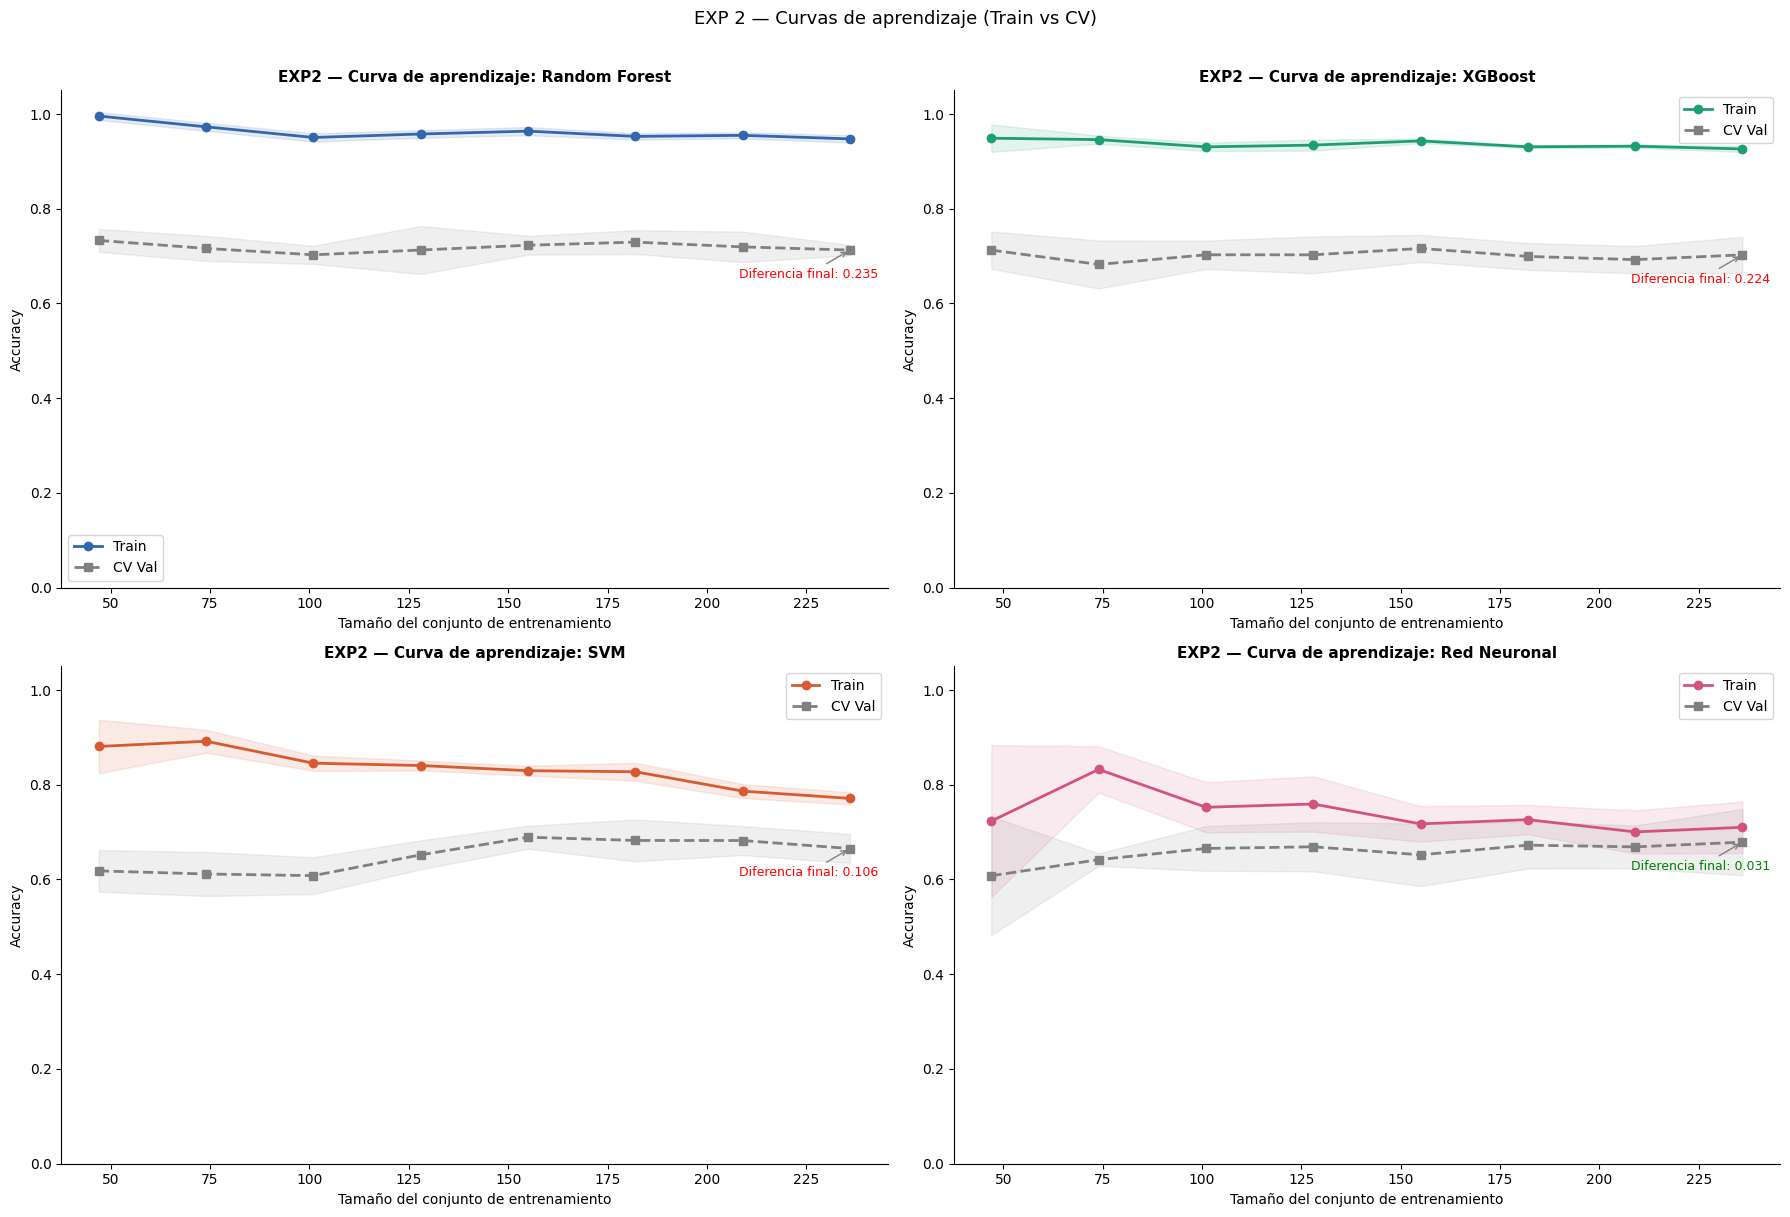

Guardada: position_output/exp2/learning_curves.png


In [25]:
# ── Curvas de aprendizaje — EXP 2 ───────────────────────────
lc_models2 = [
    ('Random Forest', rf2,  '#3266ad'),
    ('XGBoost',       xgb2, '#1d9e75'),
    ('SVM',           svm2, '#d85a30'),
    ('Red Neuronal',  mlp2, '#d4537e'),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, (mname, model, color) in zip(axes, lc_models2):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X2_train_sc, y2_train,
        cv=cv5, scoring='accuracy',
        train_sizes=np.linspace(0.2, 1.0, 8),
        n_jobs=-1
    )
    tr_mean  = train_scores.mean(axis=1)
    tr_std   = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std  = val_scores.std(axis=1)

    ax.plot(train_sizes, tr_mean,  'o-', color=color,   label='Train',  linewidth=2)
    ax.plot(train_sizes, val_mean, 's--', color='gray', label='CV Val', linewidth=2)
    ax.fill_between(train_sizes, tr_mean - tr_std,  tr_mean + tr_std,  alpha=0.12, color=color)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.12, color='gray')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'EXP2 — Curva de aprendizaje: {mname}', fontsize=11, fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.spines[['top', 'right']].set_visible(False)
    Diferencia = tr_mean[-1] - val_mean[-1]
    ax.annotate(f'Diferencia final: {Diferencia:.3f}',
                xy=(train_sizes[-1], val_mean[-1]),
                xytext=(-80, -20), textcoords='offset points',
                fontsize=9, color='red' if Diferencia > 0.10 else 'green',
                arrowprops=dict(arrowstyle='->', color='gray'))

plt.suptitle('EXP 2 — Curvas de aprendizaje (Train vs CV)', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp2/learning_curves.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Guardada: {OUT_ROOT}/exp2/learning_curves.png')


### 2.8 Análisis SHAP — EXP 2 (mejor modelo)

Mejor modelo EXP2: Random Forest  (0.7467)


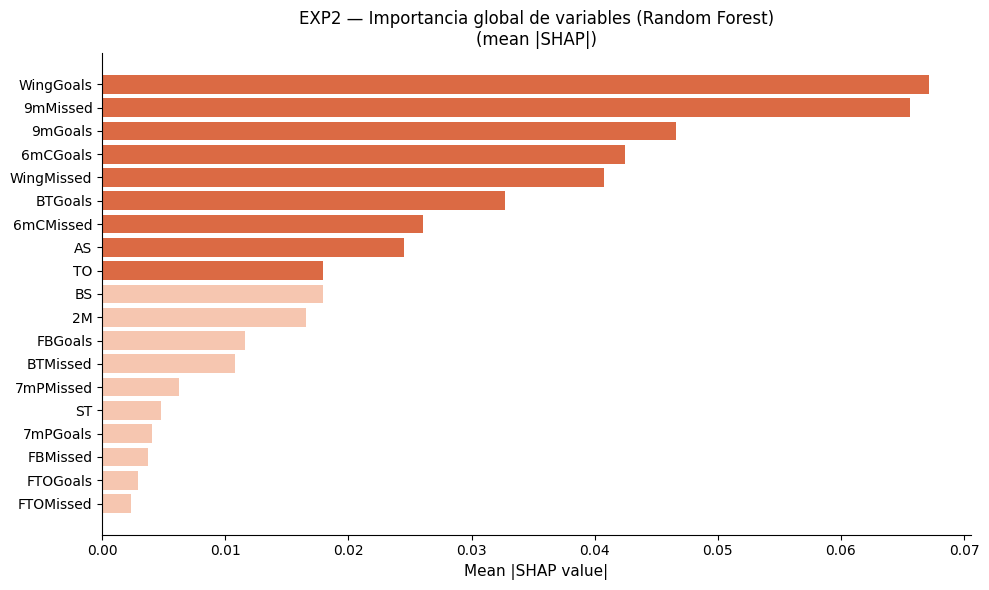


Top 10 variables más importantes (EXP2):


,mean_abs_shap
WingGoals,0.0672
9mMissed,0.0656
9mGoals,0.0466
6mCGoals,0.0424
WingMissed,0.0408
BTGoals,0.0327
6mCMissed,0.0260
AS,0.0245
TO,0.0180
BS,0.0179


In [26]:
accs2 = {name: accuracy_score(y2_test, p) for name, p in models_exp2}
best_name2 = max(accs2, key=accs2.get)
best_model2_map = {'Random Forest': rf2, 'XGBoost': xgb2}
shap_model2_name = best_name2 if best_name2 in best_model2_map else 'XGBoost'
shap_model2 = best_model2_map[shap_model2_name]
print(f'Mejor modelo EXP2: {best_name2}  ({accs2[best_name2]:.4f})')

X2_all_sc = scaler2.transform(X2)
explainer2 = shap.TreeExplainer(shap_model2)
shap_vals2 = explainer2.shap_values(X2_all_sc)

if isinstance(shap_vals2, list):
    global_shap2 = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals2], axis=0)
else:
    global_shap2 = np.abs(shap_vals2).mean(axis=(0, 2)) if shap_vals2.ndim == 3 else np.abs(shap_vals2).mean(axis=0)

shap_imp2 = pd.Series(global_shap2, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar2 = ['#d85a30' if v > shap_imp2.median() else '#f5c0a8' for v in shap_imp2.values]
ax.barh(shap_imp2.index[::-1], shap_imp2.values[::-1], color=colors_bar2[::-1], alpha=0.9)
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title(f'EXP2 — Importancia global de variables ({shap_model2_name})\n(mean |SHAP|)', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp2/shap_global_importance.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nTop 10 variables más importantes (EXP2):')
display(shap_imp2.head(10).to_frame('mean_abs_shap').round(4))

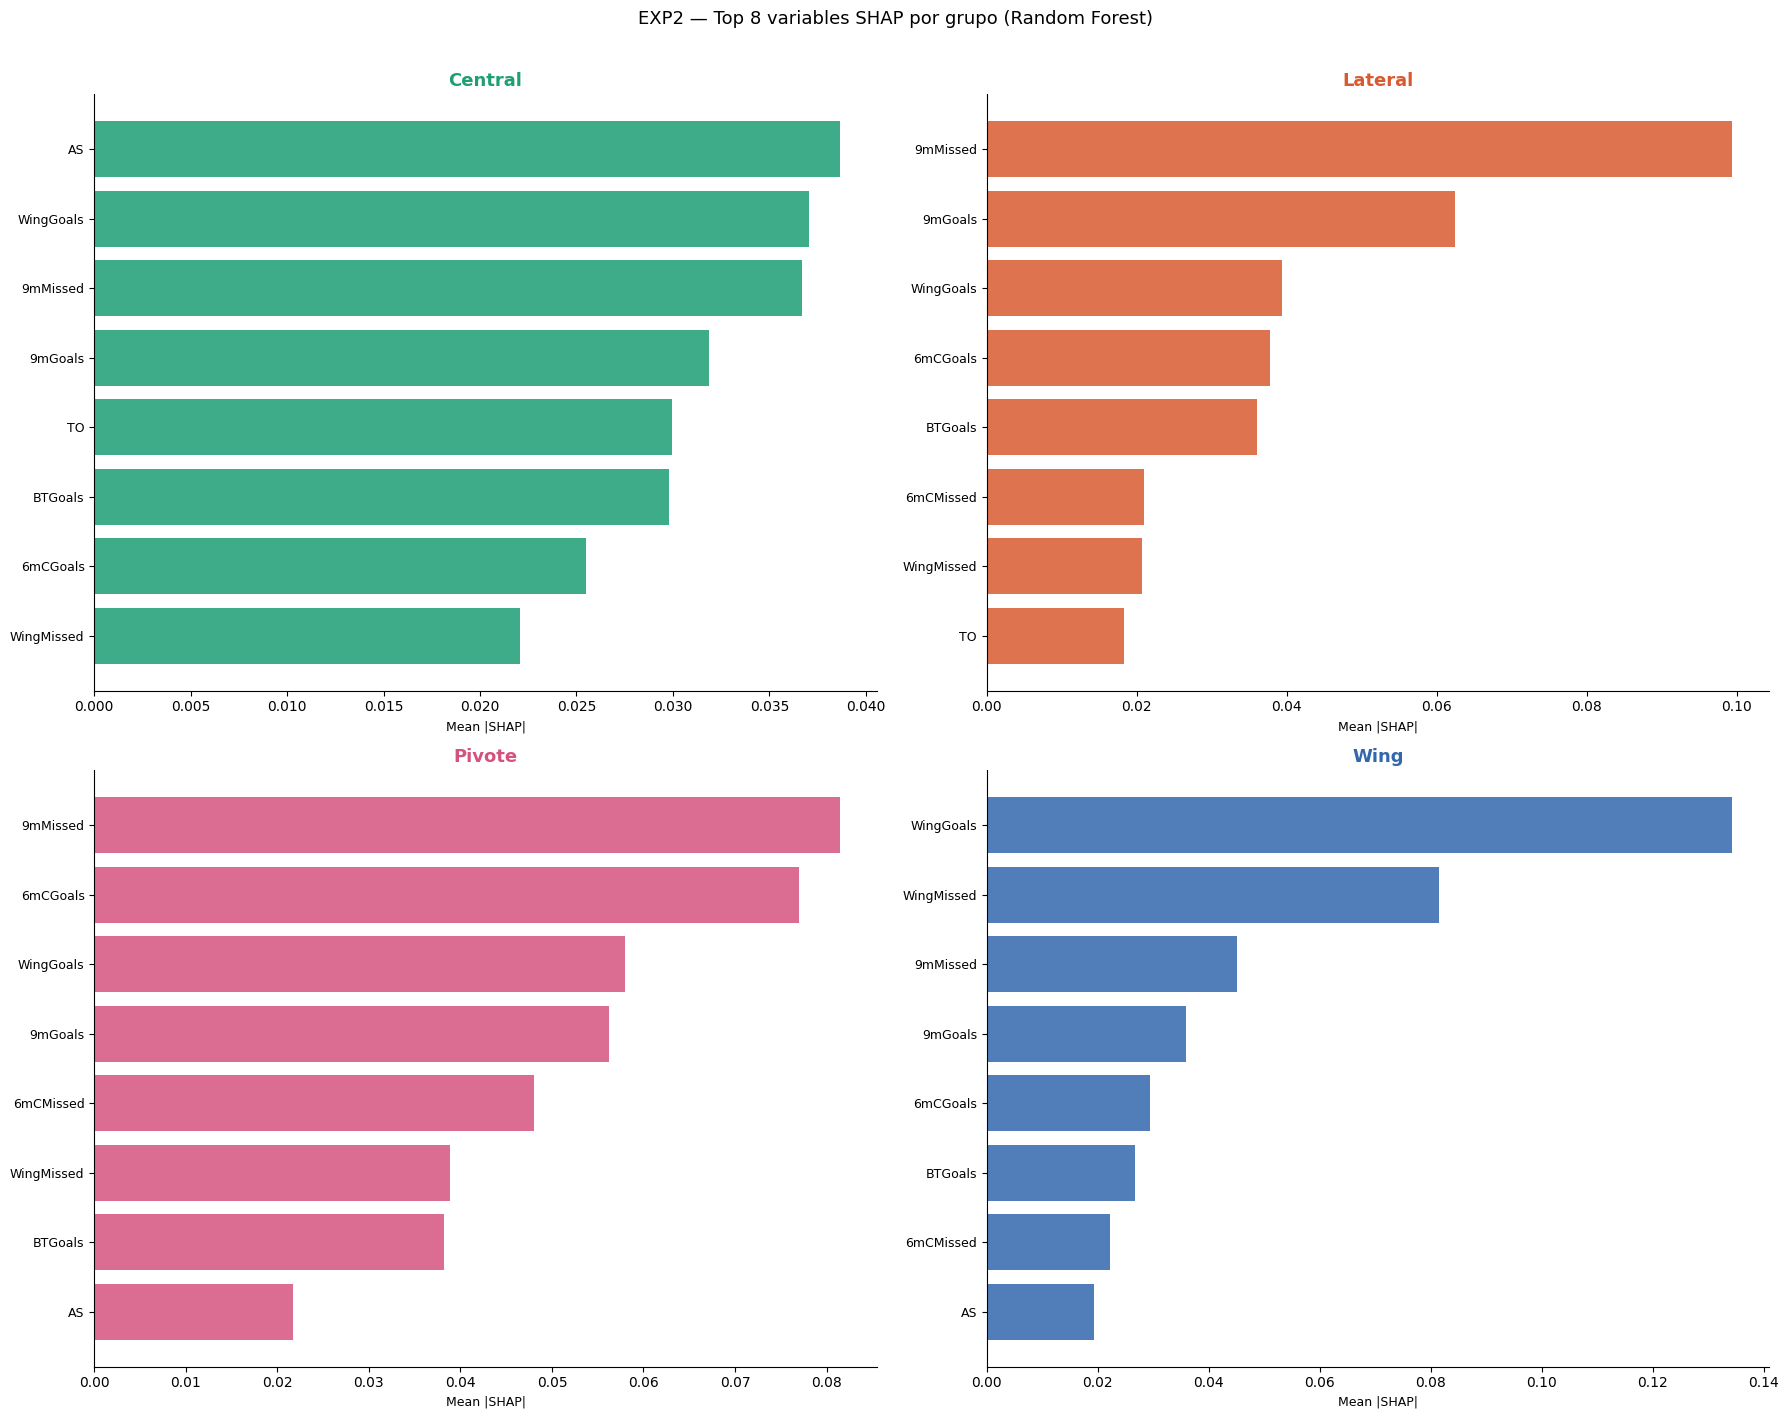

Guardada: position_output/exp2/shap_per_group.png


In [27]:
# SHAP por grupo — EXP2
if isinstance(shap_vals2, list):
    shap_list2 = shap_vals2
elif shap_vals2.ndim == 3:
    shap_list2 = [shap_vals2[:, :, i] for i in range(shap_vals2.shape[2])]
else:
    shap_list2 = [shap_vals2]

classes2 = le2.classes_
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, cls in enumerate(classes2):
    sv = shap_list2[idx]
    mean_abs = np.abs(sv).mean(axis=0)
    importance = pd.Series(mean_abs, index=FEATURE_COLS).sort_values(ascending=False)
    top_vars = importance.head(TOP_N)
    color = POS_COLORS.get(cls, '#888')
    ax = axes[idx]
    ax.barh(range(TOP_N), top_vars.values[::-1], color=color, alpha=0.85)
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_vars.index[::-1], fontsize=9)
    ax.set_xlabel('Mean |SHAP|', fontsize=9)
    ax.set_title(f'{cls}', fontsize=13, fontweight='bold', color=color)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'EXP2 — Top {TOP_N} variables SHAP por grupo ({shap_model2_name})',
             fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/exp2/shap_per_group.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Guardada: {OUT_ROOT}/exp2/shap_per_group.png')

---

# ══════════════════════════════════════════
# COMPARATIVA ENTRE EXPERIMENTOS
# ══════════════════════════════════════════

  RESUMEN DE EXPERIMENTOS

--- EXP 1 (6 clases) ---


,Accuracy,F1 (weighted),F1 (macro),CV Accuracy (mean)
Modelo,,,,
Random Forest,0.4267,0.4280,0.4093,0.5067
XGBoost,0.4800,0.4638,0.4341,0.4797
SVM,0.4800,0.4884,0.4586,0.5003
Red Neuronal,0.4000,0.4183,0.3905,0.4867



--- EXP 2 (4 clases) ---


,Accuracy,F1 (weighted),F1 (macro),CV Accuracy (mean)
Modelo,,,,
Random Forest,0.7467,0.7413,0.7221,0.7196
XGBoost,0.7200,0.7095,0.6874,0.7129
SVM,0.6267,0.6187,0.6292,0.6654
Red Neuronal,0.6933,0.6555,0.6170,0.7229


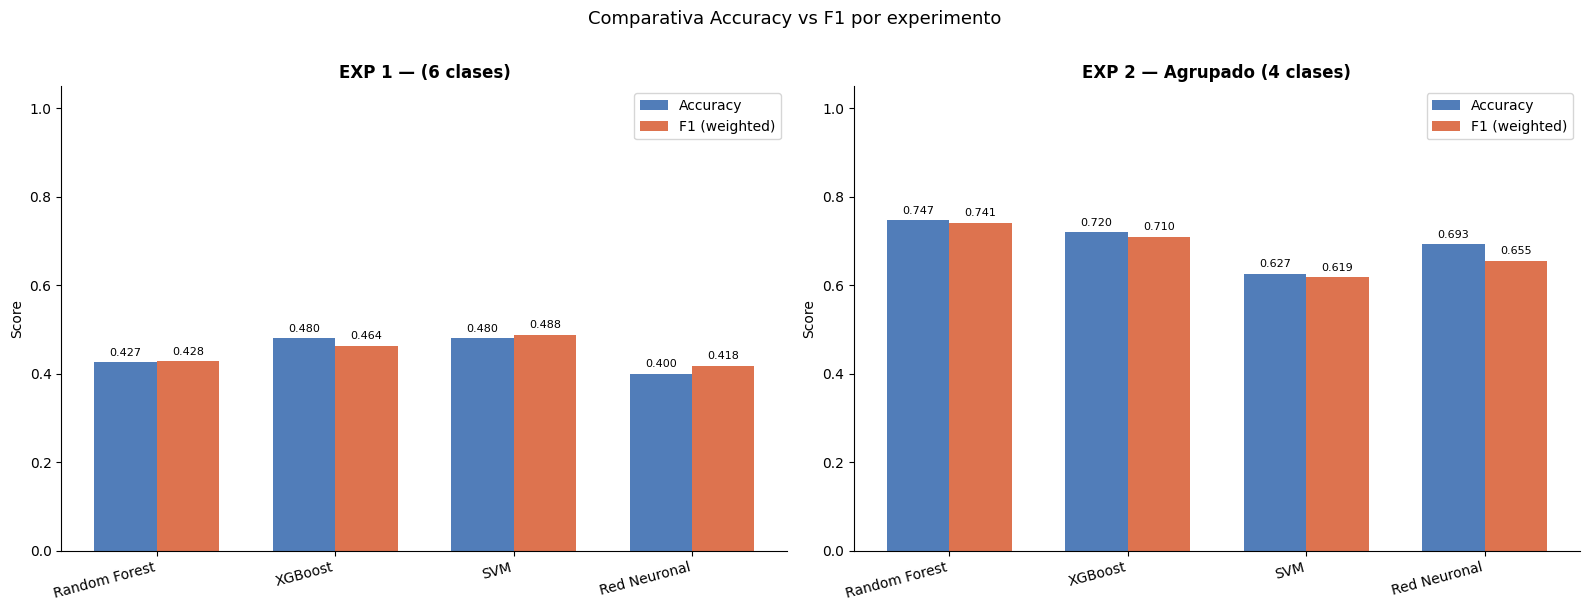

✓ Guardada: position_output/comparativa_experimentos.png


In [28]:
print('=' * 55)
print('  RESUMEN DE EXPERIMENTOS')
print('=' * 55)
print('\n--- EXP 1 (6 clases) ---')
display(df_metrics_exp1[['Accuracy', 'F1 (weighted)', 'F1 (macro)', 'CV Accuracy (mean)']])

print('\n--- EXP 2 (4 clases) ---')
display(df_metrics_exp2[['Accuracy', 'F1 (weighted)', 'F1 (macro)', 'CV Accuracy (mean)']])

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
for ax, (df_met, title) in zip(axes, [
    (df_metrics_exp1, 'EXP 1 — (6 clases)'),
    (df_metrics_exp2, 'EXP 2 — Agrupado (4 clases)'),
]):
    x = range(len(df_met))
    width = 0.35
    bars1 = ax.bar([i - width/2 for i in x], df_met['Accuracy'],
                   width, label='Accuracy', color='#3266ad', alpha=0.85)
    bars2 = ax.bar([i + width/2 for i in x], df_met['F1 (weighted)'],
                   width, label='F1 (weighted)', color='#d85a30', alpha=0.85)
    ax.set_xticks(list(x))
    ax.set_xticklabels(df_met.index, rotation=15, ha='right')
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparativa Accuracy vs F1 por experimento', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/comparativa_experimentos.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'✓ Guardada: {OUT_ROOT}/comparativa_experimentos.png')

---

# ══════════════════════════════════════════
# MODELO FINAL ROBUSTO
# Entrenar con el 100% de los datos (train+test)
# una vez validados los experimentos
# ══════════════════════════════════════════

> **Nota metodológica**: los experimentos anteriores validan los modelos con el split 80/20. Una vez elegido el mejor modelo y sus hiperparámetros (sin reajuste), se entrena sobre el 100% del dataset disponible para maximizar la capacidad predictiva del modelo final. No se calculan métricas de test sobre este modelo (no habría datos reservados); su evaluación queda garantizada por los resultados anteriores.

In [29]:
# ── EXP 1 — Modelo final sobre todos los datos (sin GK) ─────
print('=== MODELO FINAL — EXP 1 (sin GK) ===')

X1_all_full = df_exp1[FEATURE_COLS].values
y1_all_full = le1.transform(df_exp1[TARGET_COL].values)

scaler1_final = StandardScaler()
X1_all_sc_final = scaler1_final.fit_transform(X1_all_full)

# Usamos los mejores hiperparámetros encontrados en el experimento
rf1_final = RandomForestClassifier(
    **gs_rf1.best_params_,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
rf1_final.fit(X1_all_sc_final, y1_all_full)
print(f'RF EXP1 final entrenado con {len(y1_all_full)} instancias. Clases: {le1.classes_}')

# ── EXP 2 — Modelo final sobre todos los datos (grupos) ─────
print('\n=== MODELO FINAL — EXP 2 (agrupado) ===')

X2_all_full = df_exp2[FEATURE_COLS].values
y2_all_full = le2.transform(df_exp2['Grupo'].values)

scaler2_final = StandardScaler()
X2_all_sc_final = scaler2_final.fit_transform(X2_all_full)

rf2_final = RandomForestClassifier(
    **gs_rf2.best_params_,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
rf2_final.fit(X2_all_sc_final, y2_all_full)
print(f'RF EXP2 final entrenado con {len(y2_all_full)} instancias. Clases: {le2.classes_}')

=== MODELO FINAL — EXP 1 (sin GK) ===
RF EXP1 final entrenado con 371 instancias. Clases: ['CB' 'LB' 'LP' 'LW' 'RB' 'RW']

=== MODELO FINAL — EXP 2 (agrupado) ===
RF EXP2 final entrenado con 371 instancias. Clases: ['Central' 'Lateral' 'Pivote' 'Wing']


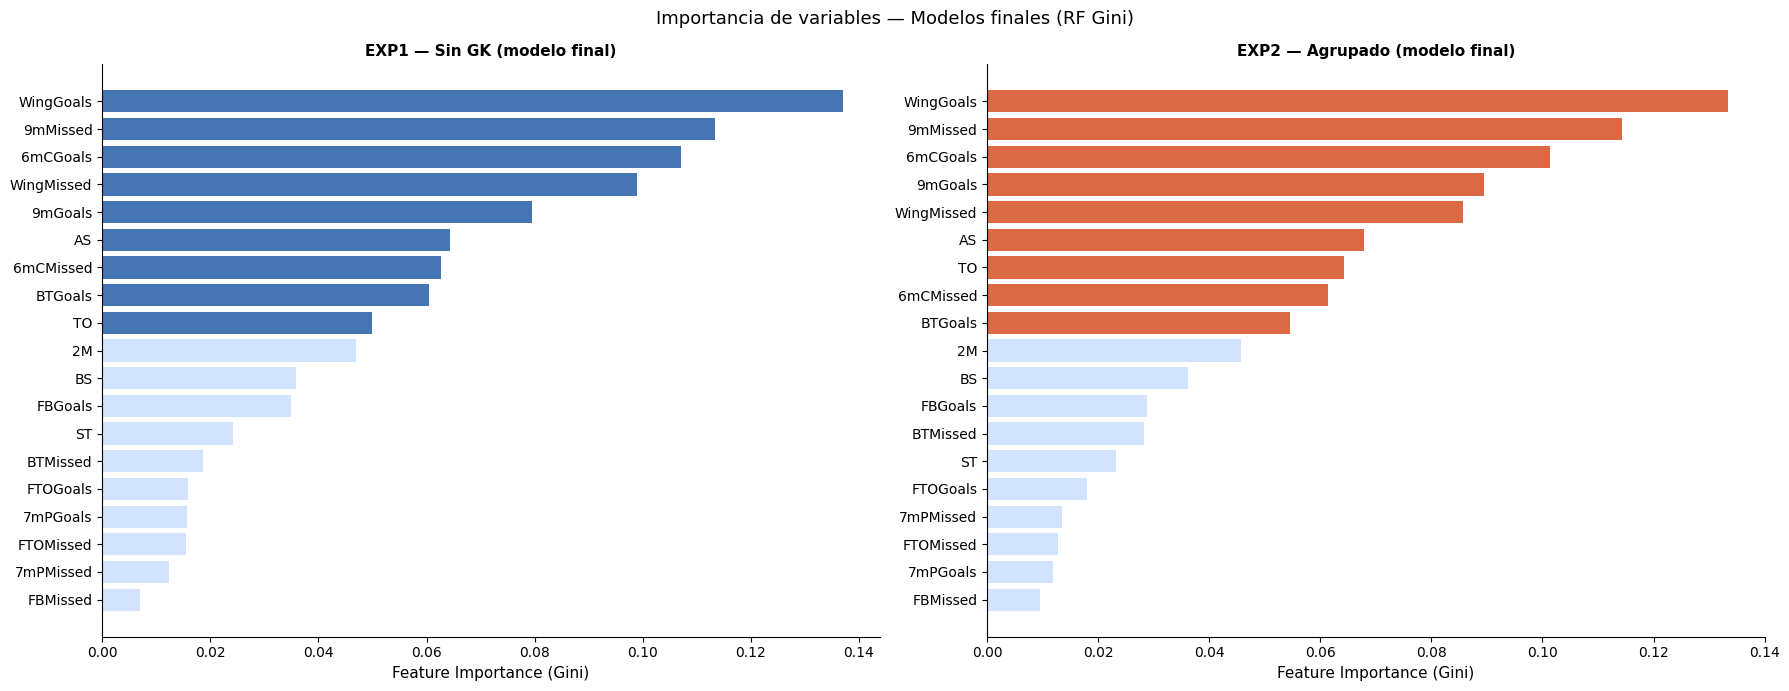

✓ Guardada: position_output/final/feature_importance_final.png
Todos los artefactos en: position_output/


In [30]:
# ── Importancia de variables del modelo final (RF, Gini) ────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (rf_fin, scaler_fin, title_exp, color_bar) in zip(axes, [
    (rf1_final, scaler1_final, 'EXP1 — Sin GK (modelo final)', '#3266ad'),
    (rf2_final, scaler2_final, 'EXP2 — Agrupado (modelo final)', '#d85a30'),
]):
    imp = pd.Series(rf_fin.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
    colors_imp = [color_bar if v > imp.median() else '#cce0ff' for v in imp.values]
    ax.barh(imp.index[::-1], imp.values[::-1], color=colors_imp[::-1], alpha=0.9)
    ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
    ax.set_title(title_exp, fontsize=11, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Importancia de variables — Modelos finales (RF Gini)', fontsize=13)
plt.tight_layout()
fig.savefig(f'{OUT_ROOT}/final/feature_importance_final.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'✓ Guardada: {OUT_ROOT}/final/feature_importance_final.png')

print(f'Todos los artefactos en: {OUT_ROOT}/')

### SHAP — Modelos finales (train+test completo)

Análisis SHAP sobre los modelos finales entrenados con el 100% de los datos. Al haber visto más ejemplos, los valores de importancia son más estables y representativos que los obtenidos durante los experimentos.


=== SHAP EXP1 — (6 clases) ===


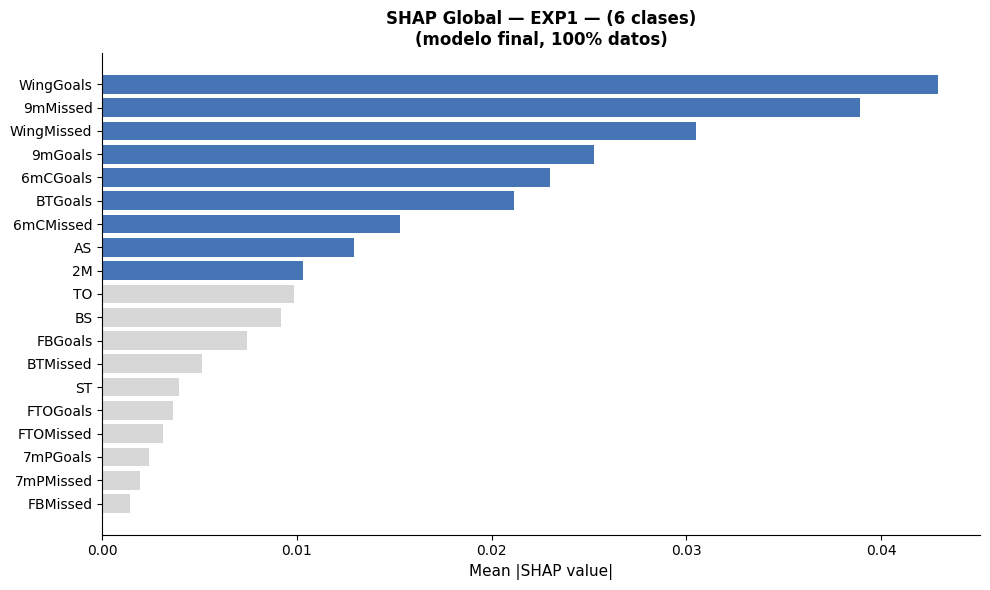

✓ position_output/final/shap_exp1_final_global.png

Top 10 variables:


,mean_abs_shap
WingGoals,0.0429
9mMissed,0.0389
WingMissed,0.0305
9mGoals,0.0252
6mCGoals,0.0230
BTGoals,0.0211
6mCMissed,0.0153
AS,0.0129
2M,0.0103
TO,0.0098


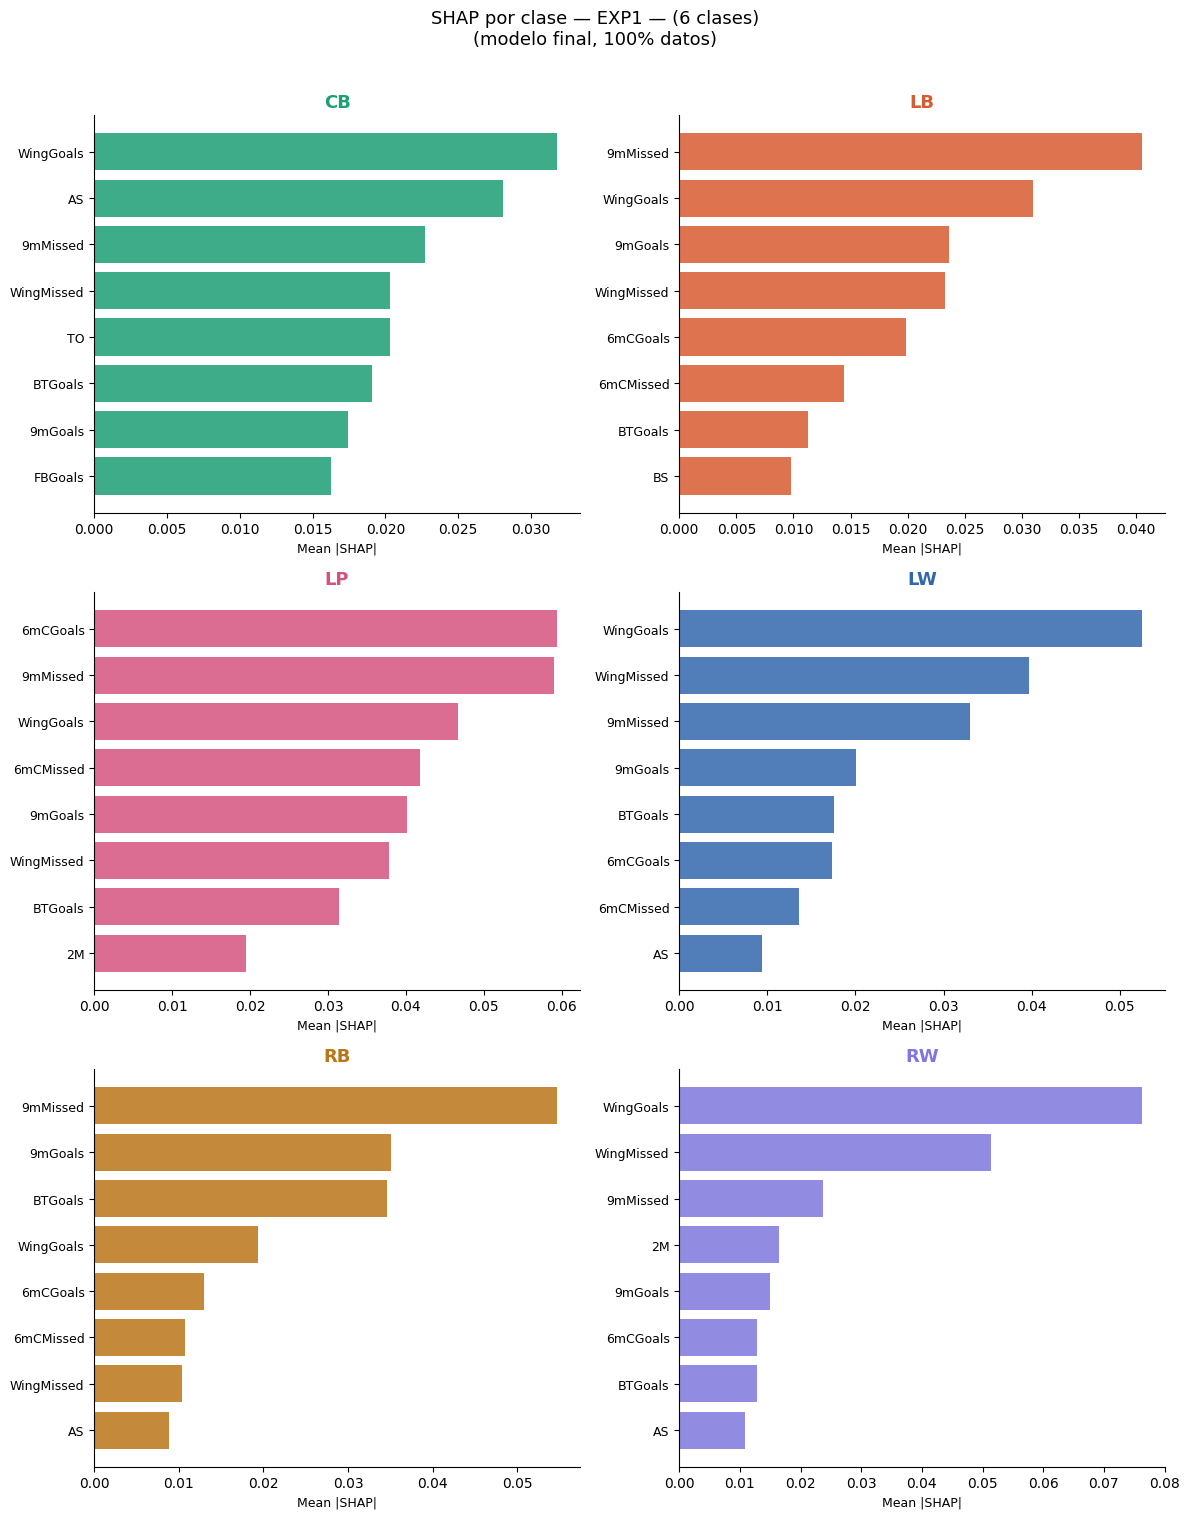

✓ position_output/final/shap_exp1_final_per_class.png

=== SHAP EXP2 — Agrupado (4 clases) ===


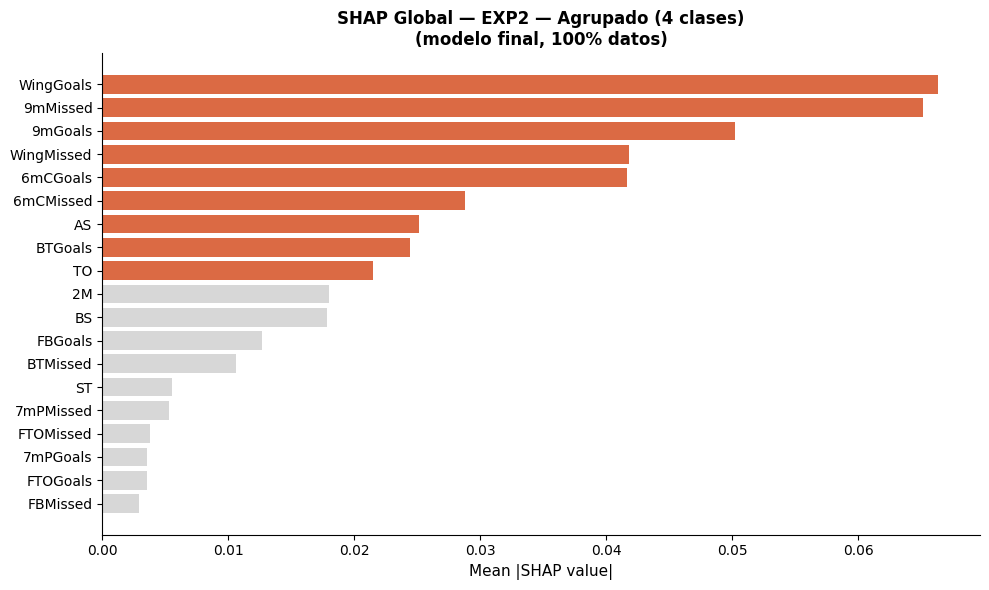

✓ position_output/final/shap_exp2_final_global.png

Top 10 variables:


,mean_abs_shap
WingGoals,0.0663
9mMissed,0.0651
9mGoals,0.0502
WingMissed,0.0418
6mCGoals,0.0416
6mCMissed,0.0288
AS,0.0252
BTGoals,0.0245
TO,0.0215
2M,0.0180


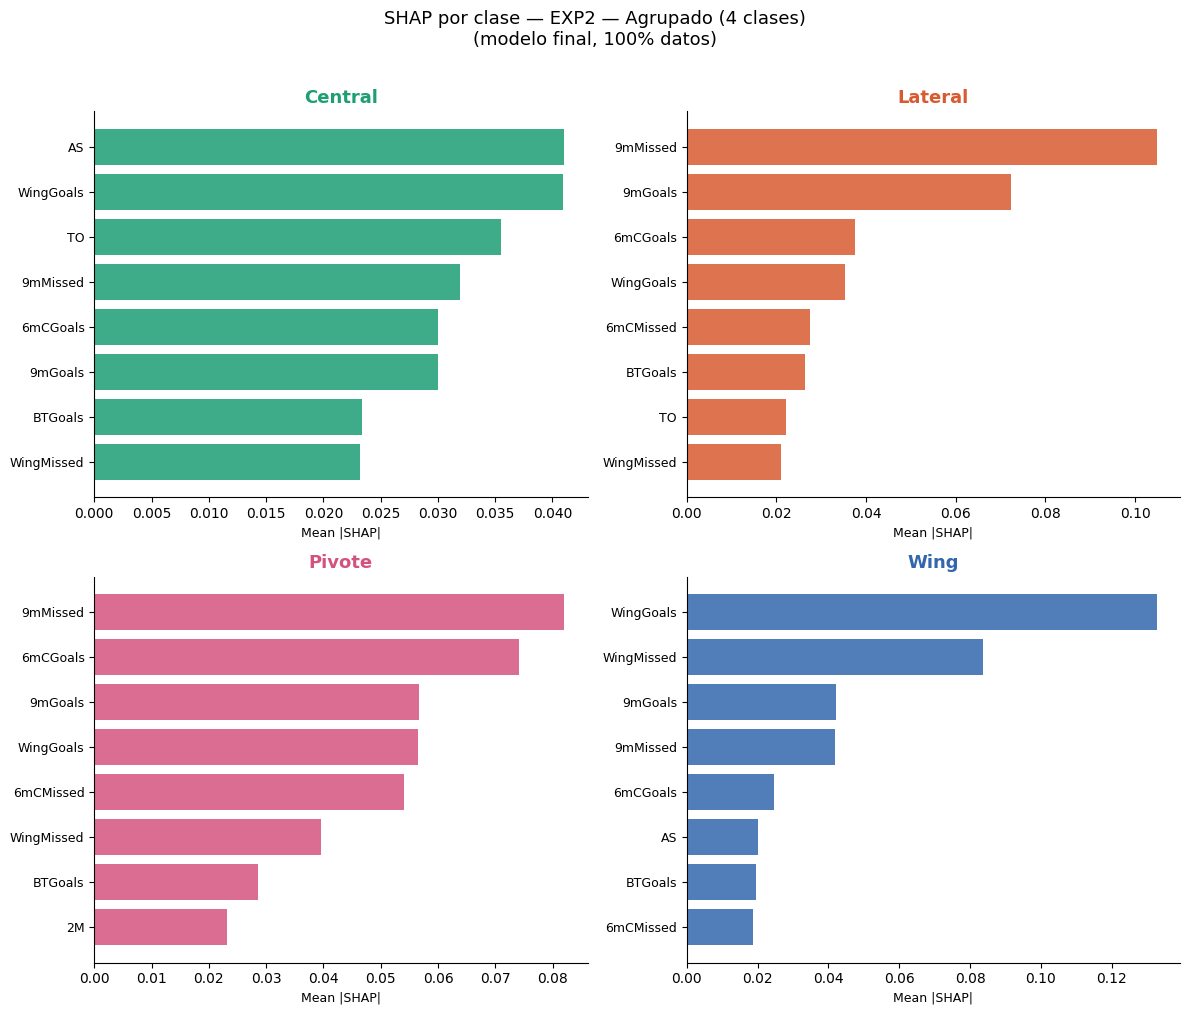

✓ position_output/final/shap_exp2_final_per_class.png


In [31]:
# ── SHAP sobre modelos finales ───────────────────────────────
finals = [
    ('EXP1 — (6 clases)', rf1_final, scaler1_final,
     df_exp1, FEATURE_COLS, TARGET_COL, le1,
     f'{OUT_ROOT}/final/shap_exp1_final', '#3266ad'),
    ('EXP2 — Agrupado (4 clases)', rf2_final, scaler2_final,
     df_exp2, FEATURE_COLS, 'Grupo', le2,
     f'{OUT_ROOT}/final/shap_exp2_final', '#d85a30'),
]

for title, model, scaler, df, feat_cols, target_col, le, out_prefix, color in finals:
    print(f'\n=== SHAP {title} ===')

    X_all = scaler.transform(df[feat_cols].values)
    y_all = le.transform(df[target_col].values)

    explainer = shap.TreeExplainer(model)
    shap_vals  = explainer.shap_values(X_all)

    # ── Importancia global (mean |SHAP|) ────────────────────
    if isinstance(shap_vals, list):
        global_imp = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)
    elif shap_vals.ndim == 3:
        global_imp = np.abs(shap_vals).mean(axis=(0, 2))
    else:
        global_imp = np.abs(shap_vals).mean(axis=0)

    shap_imp = pd.Series(global_imp, index=feat_cols).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors_bar = [color if v > shap_imp.median() else '#d3d3d3' for v in shap_imp.values]
    ax.barh(shap_imp.index[::-1], shap_imp.values[::-1], color=colors_bar[::-1], alpha=0.9)
    ax.set_xlabel('Mean |SHAP value|', fontsize=11)
    ax.set_title(f'SHAP Global — {title}\n(modelo final, 100% datos)', fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    fig.savefig(f'{out_prefix}_global.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f'✓ {out_prefix}_global.png')

    print('\nTop 10 variables:')
    display(shap_imp.head(10).to_frame('mean_abs_shap').round(4))

    # ── SHAP por clase ───────────────────────────────────────
    if isinstance(shap_vals, list):
        shap_list = shap_vals
    elif shap_vals.ndim == 3:
        shap_list = [shap_vals[:, :, i] for i in range(shap_vals.shape[2])]
    else:
        shap_list = [shap_vals]

    classes  = le.classes_
    n_cls    = len(classes)
    n_cols   = min(n_cls, 2)
    n_rows   = math.ceil(n_cls / n_cols)
    TOP_N    = 8

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
    axes = np.array(axes).flatten()

    for idx, cls in enumerate(classes):
        sv       = shap_list[idx]
        mean_abs = np.abs(sv).mean(axis=0)
        top_vars = pd.Series(mean_abs, index=feat_cols).sort_values(ascending=False).head(TOP_N)
        cls_color = POS_COLORS.get(cls, color)
        ax = axes[idx]
        ax.barh(range(TOP_N), top_vars.values[::-1], color=cls_color, alpha=0.85)
        ax.set_yticks(range(TOP_N))
        ax.set_yticklabels(top_vars.index[::-1], fontsize=9)
        ax.set_xlabel('Mean |SHAP|', fontsize=9)
        ax.set_title(cls, fontsize=13, fontweight='bold', color=cls_color)
        ax.spines[['top', 'right']].set_visible(False)

    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f'SHAP por clase — {title}\n(modelo final, 100% datos)',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    fig.savefig(f'{out_prefix}_per_class.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ {out_prefix}_per_class.png')